# Implementation Roadmap
## LLM as a judge
### Must-have (ship first)
- **Strict JSON schema + retry-on-fail**  
  Ensures well-formed, consistent outputs.  

- **Multi-trace CoT (k=3–5) + self-confidence**  
  Generate multiple reasoning traces; each trace provides its own confidence score.  

- **Weighted voting by self-confidence**  
  Aggregate values using confidence weights instead of plain majority.  

- **Evidence grounding (span linking)**  
  Judge must cite exact supporting text spans; missing evidence → lower confidence.  

- **Domain validators (hard/soft rules)**  
  - Dates follow expected formats  
  - VAT ID / IBAN checksum validation  
  - `Gross ≈ Net + VAT` (within tolerance)  
  - Currency whitelist checks  

- **Per-field calibration**  
  Map raw confidence to true correctness probability (e.g., isotonic or temperature scaling).  

- **Acceptance policy**  
  Apply per-field thresholds; for documents, require all critical fields to pass.  

- **Auditing & provenance**  
  Store chosen value, calibrated confidence, cited spans, validator outcomes, and reasoning traces.  

---

### High-impact add-ons (still no training)
- **Dual-phase reasoning**  
  1. Solution reasoning → generate answer  
  2. Confidence reasoning → judge and verbalize confidence bin (0–9 or 0–1)  

- **Difficulty-aware sampling**  
  Use vote dispersion or evidence quality to stop early on easy fields or sample more traces for hard ones.  

- **Cross-judge diversity (multiple rubrics)**  
  Run the same model with different judging rubrics and combine results:  
  - *Format-strict judge*: strict regex/format checks (e.g., dates, VAT IDs)  
  - *Arithmetic-strict judge*: check totals and sums (e.g., Gross vs. Net + VAT)  
  - *Evidence-strict judge*: require supporting spans near relevant anchors (e.g., “VAT”, “Total”)  

- **Few-shot bank (prompt-only)**  
  Maintain a curated set of vendor/layout examples; update as new reviewed cases are added.  

---

### Ops & monitoring
- **Coverage vs. accuracy dashboards**  
  Track Brier, ECE, NLL, AUROC; monitor auto-accept vs. review rates.  

- **Periodic recalibration**  
  Refresh calibration mappings as new reviewed cases arrive.  

- **Fail-safes**  
  If JSON invalid or confidence unstable → deterministic re-ask at temperature=0; else route to review.  


<style>
open { color: Red }
inprogress { color: Yellow }
done { color: Green; text-decoration: line-through }
</style>

# First steps
To start things off, we need to build a simple LLM-as-a-Judge (LaaJ) setup<br>
For this we need to do prepare the following:
- <done>Access to the Azure hosted GPT5-mini</done>
- <done>Access to the data located on the NAS</done>

Then we need to force the LLM to create multiple reasoning paths for one input.<br>
- <done>Actively encourage the LLM to perform "slow thinking" and prepare a json output schema the data needs to fit in.</done><br>
- <done>Implement a retry option (with amount of retries as a parameter) to catch LLM errors.</done><br>
- <open>Peform validity checks for produced outputs (Valid VAT layout, isNumber for amounts, ...). If these checks fail --> confidence decrease / set to 0.</open><br>
- <done>Query the LLM to rate its own output using numeric and written bins (10 bins, [0.0; 0.1], [0.1; 0.2], ...)</done><br>
- <done>Implement weighted majority voting based on confidence (Borda voting with exponent)</done><br>

<done>Visualize the results of perceived confidence and actual correctness in a bar chart (should be x=y for perfect prediction)</done><br>


# LLM Setup

In [5]:
# --- setup: remove retries, unused vars, fix concurrent name, simpler mkdir ---
from datetime import datetime
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import AsyncOpenAI
import logging
import json

load_dotenv(override=True)

DOCUMENT_STORAGE = Path(os.getenv("DOCUMENT_STORAGE"))
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
DEPLOYMENT_NAME = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")

client = AsyncOpenAI(api_key=API_KEY, base_url=ENDPOINT)

CONCURRENT_TASKS = 15

# # Pricing (EUR per 1M tokens) for GPT-5-mini
PRICE_INPUT_EUR_PER_MTOK = 0.22
PRICE_CACHED_INPUT_EUR_PER_MTOK = 0.03
PRICE_OUTPUT_EUR_PER_MTOK = 1.73

# Pricing (EUR per 1M tokens) for GPT-5-nano
# PRICE_INPUT_EUR_PER_MTOK = 0.05
# PRICE_CACHED_INPUT_EUR_PER_MTOK = 0.01
# PRICE_OUTPUT_EUR_PER_MTOK = 0.35

logging_path = Path("../Logs")
logging_path.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=f"{logging_path}/{DEPLOYMENT_NAME}_{TIMESTAMP}.log",
    filemode="a",
    format="%(asctime)s - %(levelname)s - %(message)s",
    level=logging.INFO,
    force=True,
)
for noisy in ["httpx", "openai", "azure", "urllib3"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

with open("../Prompts/system_prompt.txt", "r", encoding="utf-8") as f:
    system_prompt = f.read()
with open("../Prompts/schema.json", "r", encoding="utf-8") as f:
    schema = json.load(f)
formatted_schema = json.dumps(schema, indent=2)
system_prompt = system_prompt.replace("formatted_schema_representation", formatted_schema)


# Helper Functions

## Fuzzy Comparison

In [6]:
import re
from typing import Any, Optional

COMPARE_FIELDS = [
    "Sender.VatId",
    "GrandTotal.Amount",
    "Net.Amount",
    "Vat.Amount",
    "Vat.Rate",
    "Invoice.Date",
]

NUMERIC_FIELDS = {
    "GrandTotal.Amount",
    "Net.Amount",
    "Vat.Amount",
    "Vat.Rate",
}


_TRAILING_RE = re.compile(r"[ \t\r\n\.,;:\-\u2013\u2014\u2011]+$")  # remove trailing whitespace, punctuation, and hyphen-like dashes

def strip_trailing_punct(x: Any) -> Optional[str]:
    if x is None:
        return None
    s = str(x).strip()
    if not s:
        return None
    return _TRAILING_RE.sub("", s)

def parse_number(x: Any) -> Optional[float]:
    """
    Improved numeric parsing:
    - Rightmost of ',' or '.' is treated as the decimal separator.
    """
    s = strip_trailing_punct(x)
    if s is None:
        return None

    # keep only digits, separators, minus
    s = re.sub(r"[^0-9,.\-]", "", s)
    if not s:
        return None

    last_dot = s.rfind(".")
    last_comma = s.rfind(",")

    if last_dot != -1 and last_comma != -1:
        # both present: rightmost decides decimal
        if last_comma > last_dot:
            # comma is decimal, dots are thousands
            s = s.replace(".", "")
            s = s.replace(",", ".")
        else:
            # dot is decimal, commas are thousands
            s = s.replace(",", "")
    elif last_comma != -1:
        # only comma present -> decimal comma
        s = s.replace(".", "")  # any stray dots treated as thousands
        s = s.replace(",", ".")

    try:
        val = float(s)
    except ValueError:
        return None

    return val


def normalize_value(field: str, value: Any):
    if field in NUMERIC_FIELDS:
        return parse_number(value)
    # Special-case: for VAT IDs, remove all internal whitespace before compare
    if field == "Sender.VatId":
        s = strip_trailing_punct(value)
        if s is None:
            return None
        return re.sub(r"\s+", "", s)
    # non-numeric: only remove trailing whitespace/punctuation
    return strip_trailing_punct(value)


def _round_numeric(val):
    if val is None:
        return None
    return round(float(val), 2)

def _normalize_element(field: str, value: Any):
    v = normalize_value(field, value)
    if field in NUMERIC_FIELDS:
        v = _round_numeric(v)
    return v

def normalize_for_compare(field: str, value):
    """Normalize values for comparison.
    - For numeric fields: parse and round
    - For text: trim trailing punctuation/whitespace; special-case VAT removes internal whitespace
    - For lists: apply element-wise normalization and drop Nones/empties
    """
    if isinstance(value, list):
        normed_list = []
        for item in value:
            nv = _normalize_element(field, item)
            if nv is None or (isinstance(nv, str) and nv == ""):
                continue
            normed_list.append(nv)
        return normed_list
    return _normalize_element(field, value)


In [7]:
import time
import asyncio
from collections import defaultdict, Counter

from openai import BadRequestError

async def _timed_request(timeout_sec: float = 60, **kwargs):
    start = time.time()
    try:
        resp = await asyncio.wait_for(client.responses.create(**kwargs), timeout=timeout_sec)
    except (asyncio.TimeoutError, BadRequestError):
        runtime = round(time.time() - start, 2)
        return None, {
            "runtime_sec": runtime,
            "input_tokens": None,
            "cached_input_tokens": None,
            "output_tokens": None,
            "total_tokens": None,
            "timed_out": True,
        }
    runtime = round(time.time() - start, 2)
    usage = getattr(resp, "usage", None)
    ptd = getattr(usage, "prompt_tokens_details", None) if usage else None
    cached = getattr(ptd, "cached_tokens", None) if ptd else None
    return resp, {
        "runtime_sec": runtime,
        "input_tokens": getattr(usage, "input_tokens", None),
        "cached_input_tokens": cached,  # now correctly populated when supported
        "output_tokens": getattr(usage, "output_tokens", None),
        "total_tokens": getattr(usage, "total_tokens", None),
        "timed_out": False,
    }

# --- helper: verify previous_response_id is indexed, with exponential backoff ---
async def _wait_until_indexed(prev_id: str, retries: int = 4, base_delay: float = 0.25) -> bool:
    prev_id = str(prev_id)
    for i in range(retries):
        try:
            # succeeds when the response is visible to the service
            await client.responses.retrieve(prev_id)
            return True
        except Exception:
            await asyncio.sleep(base_delay * (2 ** i))
    return False

# --- helper: try chaining; on 400 prev-id-not-found, auto-fallback to inline context ---
async def _request_with_verified_chain(*, step_label: str, previous_response, inline_context: str | None, **kwargs):
    prev_id = getattr(previous_response, "id", None)
    if prev_id:
        ok = await _wait_until_indexed(prev_id)
        if ok:
            try:
                return await _timed_request(previous_response_id=str(prev_id), **kwargs)
            except BadRequestError as e:
                msg = str(e)
                if "previous_response_id" in msg and "not found" in msg:
                    print(f"[WARN] {step_label}: previous_response_id not found -> {prev_id}. Falling back to inline context.")
                else:
                    raise
        else:
            print(f"[WARN] {step_label}: previous_response_id not indexed -> {prev_id}. Falling back to inline context.")

    # Fallback: append prior notes directly to input and call without chaining
    new_kwargs = dict(kwargs)
    if inline_context:
        new_kwargs["input"] = f"{kwargs.get('input','')}\n\n=== CONTEXT FROM PREVIOUS STEP ===\n{inline_context}"
    return await _timed_request(**new_kwargs)



CONFIDENCE_CLASSES = [
    "Almost no chance",
    "Highly unlikely",
    "Chances are slight",
    "Unlikely",
    "Less than even",
    "Better than even",
    "Likely",
    "Very good chance",
    "Highly likely",
    "Almost certain"
]

def score_to_verbal(score: float) -> str:
    s = 0.0 if score is None else float(score)
    s = max(0.0, min(1.0, s))
    bounds = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    idx = max(i for i, b in enumerate(bounds) if s >= b)
    return CONFIDENCE_CLASSES[idx]


def _extract_reasoning_text(resp) -> str:
    chunks = []
    for item in getattr(resp, "output", []) or []:
        if getattr(item, "type", "") == "reasoning":
            summary = getattr(item, "summary", None)
            if isinstance(summary, list):
                for seg in summary:
                    t = getattr(seg, "text", None)
                    if t:
                        chunks.append(t)
            for seg in getattr(item, "content", []) or []:
                t = getattr(seg, "text", None)
                if t:
                    chunks.append(t)
    if chunks:
        return "\n".join(chunks).strip()
    return getattr(resp, "output_text", "") or ""

def _coerce_answer_dict(ans: dict) -> dict:
    if isinstance(ans, dict) and "properties" in ans and "values" in ans:
        v = ans.get("values")
        return v if isinstance(v, dict) else ans
    return ans if isinstance(ans, dict) else {}



def _gt_path_for_txt(txt_path):
    p = Path(txt_path)
    stem_id = p.stem.split("_")[0]  
    return sorted(p.parent.glob(f"{stem_id}*.json"))[0]


def _norm_scalar(v):
    if v is None:
        return ""
    if isinstance(v, (int, float, bool)):
        return str(v)
    return str(v).strip()


def _flatten_gt(gt: dict) -> dict:
    out = defaultdict(list)
    for node in gt.get("DocumentEssentials", []) or []:
        label = node.get("Label")
        items = node.get("Items")
        if items:
            # e.g., "Vat.Item" group: collect sub-labels into lists
            for sub in items:
                sub_label = sub.get("Label")
                sub_text = sub.get("Text")
                if sub_label:
                    out[sub_label].append(_norm_scalar(sub_text))
        else:
            text = node.get("Text")
            if label:
                out[label].append(_norm_scalar(text))
    # collapse singletons to scalars
    flat = {}
    for k, vals in out.items():
        vals = [v for v in vals if v != ""]
        flat[k] = vals[0] if len(vals) == 1 else vals
    return flat

def _to_multiset(v):
    if isinstance(v, list):
        return Counter(v)
    return Counter([v])

def _dedupe_preserve_order(seq):
    seen = set()
    out = []
    for item in seq:
        key = item
        if not isinstance(item, (str, int, float, bool)) and item is not None:
            try:
                key = json.dumps(item, sort_keys=True, ensure_ascii=False)
            except Exception:
                key = str(item)
        if key in seen:
            continue
        seen.add(key)
        out.append(item)
    return out

def compare_with_ground_truth(answer_dict: dict, txt_path: str | Path):
    gt_path = _gt_path_for_txt(txt_path)
    if not Path(gt_path).exists():
        return {
            "ground_truth_path": str(gt_path),
            "per_field": {},
            "summary": {"matched": 0, "total": 0, "all_match": False, "note": "ground truth not found"},
        }

    gt_json = json.loads(Path(gt_path).read_text(encoding="utf-8"))
    gt_flat = _flatten_gt(gt_json)

    fields_to_check = [f for f in COMPARE_FIELDS if f in gt_flat or f in answer_dict]
    per_field = {}
    num_matched = 0

    for field in fields_to_check:
        llm_raw = answer_dict.get(field, None)
        gt_raw = gt_flat.get(field, None)

        # Skip if GT is explicitly missing: []
        if isinstance(gt_raw, list) and len(gt_raw) == 0:
            continue

        llm_norm = normalize_for_compare(field, llm_raw)
        gt_norm = normalize_for_compare(field, gt_raw)

        # Also skip if GT normalizes to an empty list
        if isinstance(gt_norm, list) and len(gt_norm) == 0:
            continue

        if isinstance(gt_norm, list):
            gt_norm = _dedupe_preserve_order(gt_norm)

        if isinstance(llm_norm, list) or isinstance(gt_norm, list):
            is_match = _to_multiset(llm_norm) == _to_multiset(gt_norm)
        else:
            is_match = llm_norm == gt_norm

        if is_match:
            num_matched += 1

        per_field[field] = [is_match, llm_raw, gt_raw]

    total = len(per_field)
    return {
        "ground_truth_path": str(gt_path),
        "per_field": per_field,
        "summary": {"matched": num_matched, "total": total, "all_match": num_matched == total},
    }



# Test Reasoning path setup

In [8]:
from pathlib import Path
import json
from datetime import datetime

def _postprocess_final_payload(payload: dict) -> dict:
    """
    Expecting payload shape:
    {
      "answer": {...},                       # dict conforming to your schema
      "confidence": {"field.path": float}    # 0..1 per field that appears in 'answer'
    }
    Returns lean record with numeric + verbal per field.
    """
    answer = _coerce_answer_dict(payload.get("answer", {}))
    conf_num = payload.get("confidence", {}) or {}

    # Build verbal per field for fields present in numeric dict
    conf_verbal = {k: score_to_verbal(v) for k, v in conf_num.items()}

    return {
        "answer": answer,
        "confidence_numeric": conf_num,
        "confidence_verbal": conf_verbal,
    }

async def run_three_step_invoice_with_reasoning(invoice_txt_path: str, output_dir: Path):
    text = Path(invoice_txt_path).read_text(encoding="utf-8")

    # Step 1 — SOLUTION REASONING
    resp1, log1 = await _timed_request(
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 1 — SOLUTION REASONING:\n"
            "Reason step by step to extract the structured invoice data from the text below. "
            "Use slow thinking (explore alternatives, verify fields). "
            "Do NOT output the final answer yet.\n\n"
            f"--- INVOICE TEXT START ---\n{text}\n--- INVOICE TEXT END ---"
        ),
        reasoning={"effort": "low"},
        max_output_tokens=4000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,  # must be stored so retrieve() can see it
    )
    if resp1 is None:
        return None
    step1_notes = _extract_reasoning_text(resp1)

    # Step 2 — CONFIDENCE REASONING (verify + chain, else inline step1_notes)
    resp2, log2 = await _request_with_verified_chain(
        step_label="STEP2",
        previous_response=resp1,
        inline_context=step1_notes,
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 2 — CONFIDENCE REASONING:\n"
            "Evaluate, step by step, how likely each extracted field is correct, based on internal consistency "
            "and evidence in the text. Do NOT output the final answer yet."
        ),
        reasoning={"effort": "low"},
        max_output_tokens=2000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,  # store so step 3 can chain to it
    )
    if resp2 is None:
        return None
    step2_notes = _extract_reasoning_text(resp2)

    # Step 3 — FINAL JSON (verify + chain to step2; fallback inlines step1+step2 notes)
    inline_both = (
        f"=== CONTEXT FROM STEP 1 ===\n{step1_notes}\n\n"
        f"=== CONTEXT FROM STEP 2 ===\n{step2_notes}"
    )
    resp3, log3 = await _request_with_verified_chain(
        step_label="STEP3",
        previous_response=resp2,
        inline_context=inline_both,
        model=DEPLOYMENT_NAME,
        instructions=system_prompt,
        input=(
            "Step 3 — FINAL OUTPUT:\n"
            "Return ONLY a single valid JSON object with this structure and nothing else:\n"
            "{\n"
            '  "answer": <your final extracted invoice data strictly following this schema: '
            f"{json.dumps(schema)}"
            ">,\n"
            '  "confidence": {\n'
            "    // For every field you output in 'answer', provide a numeric confidence in [0,1].\n"
            '    // Use the exact same field keys as in "answer". For nested fields, use dot-notation keys.\n'
            '    // Example: "Net.Amount": 0.82\n'
            "  }\n"
            "}\n"
        ),
        reasoning={"effort": "low"},
        max_output_tokens=2000,
        text={"verbosity": "low"},
        user="laaj-batch",
        store=True,
    )
    if resp3 is None:
        return None

    try:
        payload = json.loads(resp3.output_text)
    except Exception:
        return None

    processed = _postprocess_final_payload(payload)
    evaluation = compare_with_ground_truth(processed['answer'], invoice_txt_path)

    itok = (log1.get("input_tokens") or 0) + (log2.get("input_tokens") or 0) + (log3.get("input_tokens") or 0)
    itok_cached = (log1.get("cached_input_tokens") or 0) + (log2.get("cached_input_tokens") or 0) + (log3.get("cached_input_tokens") or 0)
    otok = (log1.get("output_tokens") or 0) + (log2.get("output_tokens") or 0) + (log3.get("output_tokens") or 0)

    billable_input = max(0, itok - itok_cached)
    cost_eur = (
        (billable_input / 1_000_000.0) * PRICE_INPUT_EUR_PER_MTOK
        + (itok_cached / 1_000_000.0) * PRICE_CACHED_INPUT_EUR_PER_MTOK
        + (otok / 1_000_000.0) * PRICE_OUTPUT_EUR_PER_MTOK
    )

    lean_record = {
        "input_path": str(invoice_txt_path),
        "answer": processed["answer"],
        "confidence_numeric": processed["confidence_numeric"],
        "confidence_verbal": processed["confidence_verbal"],
        "reasoning": {"step1": step1_notes, "step2": step2_notes},
        "llm_logs": {"step1": log1, "step2": log2, "step3": log3},
        "evaluation": evaluation,
        "cost": {
            "input_tokens": itok,
            "cached_input_tokens": itok_cached,
            "output_tokens": otok,
            "eur_estimate": round(cost_eur, 6),
        },
    }

    out_path = output_dir / (Path(invoice_txt_path).stem + ".json")
    out_path.write_text(json.dumps(lean_record, ensure_ascii=False, indent=2), encoding="utf-8")
    return lean_record



# Add weighted majority voting

In [ ]:
# Concurrent weighted majority voting with bounded parallelism
import asyncio
from collections import defaultdict
import json
from pathlib import Path

def _key(v):
    # hashable key for dict/list/float/string values
    if isinstance(v, (str, int, float, bool)) or v is None:
        return v
    return json.dumps(v, sort_keys=True, ensure_ascii=False)

def _weighted_majority(flat_runs):
    consensus_result = {}
    debug_info = {}

    all_fields = set().union(*[r["answer"].keys() for r in flat_runs])
    for field in all_fields:
        sum_confidence = defaultdict(float)
        vote_count = defaultdict(int)

        for run in flat_runs:
            if field in run["answer"]:
                value = run["answer"][field]
                confidence = float(run["confidence_numeric"].get(field, 1.0) or 1.0)
                key = _key(value)
                sum_confidence[key] += confidence
                vote_count[key] += 1

        if sum_confidence:
            # pick value with max accumulated confidence; tie-break by count
            best_key = max(sum_confidence, key=lambda k: (sum_confidence[k], vote_count[k]))
            try:
                best_value = json.loads(best_key)
            except Exception:
                best_value = best_key

            consensus_result[field] = {
                "value": best_value,
                "sum_confidence": round(sum_confidence[best_key], 2),
                "vote_count": vote_count[best_key],
                "avg_confidence": round(sum_confidence[best_key] / max(1, vote_count[best_key]), 2),
            }
            debug_info[field] = {
                "sum_conf_per_value": {k: round(v, 2) for k, v in sum_confidence.items()},
                "counts": dict(vote_count),
            }

    return consensus_result, debug_info

async def run_self_consistent_invoice(
    invoice_txt_path: str,
    n_paths: int = 5,
    sem: asyncio.Semaphore | None = None,
    base_dir: Path | None = None,
):
    stem = Path(invoice_txt_path).stem                          
    file_id = stem.split("_")[0]                                

    # Use provided base_dir or create a local one (only for standalone usage)
    root_out = base_dir or Path(f"../Output/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")
    root_out.mkdir(parents=True, exist_ok=True)

    # Per-file subfolder by ID
    file_dir = root_out / file_id
    file_dir.mkdir(parents=True, exist_ok=True)

    local_sem = sem or asyncio.Semaphore(CONCURRENT_TASKS)

    async def _bounded_run(out_dir: Path):
        async with local_sem:
            return await run_three_step_invoice_with_reasoning(invoice_txt_path, out_dir)

    tasks = []
    for i in range(n_paths):
        out_dir = file_dir / f"rep_{i+1}"
        out_dir.mkdir(parents=True, exist_ok=True)
        tasks.append(asyncio.create_task(_bounded_run(out_dir)))

    runs = await asyncio.gather(*tasks)
    runs = [r for r in runs if r is not None]  # drop failed traces

    flat_runs = [{"answer": r["answer"], "confidence_numeric": r.get("confidence_numeric", {})} for r in runs]
    final_answer, debug = _weighted_majority(flat_runs)

    # Add correctness assesment to consensus
    answer_values = {
        f: (e.get("value") if isinstance(e, dict) else e)
        for f, e in final_answer.items()
    }
    try:
        evaluation = compare_with_ground_truth(answer_values, invoice_txt_path)
        per_field_eval = evaluation.get("per_field", {}) or {}
        for f, entry in final_answer.items():
            is_match = None
            if f in per_field_eval:
                is_match = bool(per_field_eval[f][0])
            if isinstance(entry, dict):
                entry["correct"] = is_match
            else:
                final_answer[f] = {"value": entry, "correct": is_match}
    except Exception:
        # If GT missing or comparison fails, mark as unknown
        for f, entry in final_answer.items():
            if isinstance(entry, dict):
                entry["correct"] = None
            else:
                final_answer[f] = {"value": entry, "correct": None}

    # Aggregate cost across usable runs
    total_input = sum((r.get("cost", {}).get("input_tokens", 0) or 0) for r in runs)
    total_cached = sum((r.get("cost", {}).get("cached_input_tokens", 0) or 0) for r in runs)
    total_output = sum((r.get("cost", {}).get("output_tokens", 0) or 0) for r in runs)
    billable_input = max(0, total_input - total_cached)
    total_cost_eur = (
        (billable_input / 1_000_000.0) * PRICE_INPUT_EUR_PER_MTOK
        + (total_cached / 1_000_000.0) * PRICE_CACHED_INPUT_EUR_PER_MTOK
        + (total_output / 1_000_000.0) * PRICE_OUTPUT_EUR_PER_MTOK
    )

    consensus = {
        "input_path": str(invoice_txt_path),
        "n_paths": n_paths,
        "final_answer": final_answer,
        "runs": runs,
        "vote_debug": debug,
        "cost": {
            "input_tokens": int(total_input),
            "cached_input_tokens": int(total_cached),
            "output_tokens": int(total_output),
            "eur_estimate": round(total_cost_eur, 6),
        }
    }
    # Write consensus into the ID subfolder
    (file_dir / "consensus.json").write_text(
        json.dumps(consensus, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return consensus

In [ ]:
# Progress bar for folder runner (async-friendly)
import asyncio
from pathlib import Path
from typing import Optional
from datetime import datetime
import random as _random

from tqdm.auto import tqdm 

async def run_invoices_in_folder(
    folder_path: str | Path,
    n_paths: int = 5,
    max_files: Optional[int] = None,
    random: bool = False,
    seed: int | None = None,
):
    folder = Path(folder_path)
    assert folder.is_dir(), f"Not a folder: {folder}"

    files = sorted(folder.rglob("*_grid_concat.txt"))
    # Deterministic random sampling if requested
    if max_files is not None and max_files > 0:
        if random:
            rng = _random.Random(seed) if seed is not None else _random
            files = list(files)
            rng.shuffle(files)
            files = files[:max_files]
        else:
            files = files[:max_files]

    run_dir = Path(f"../Output/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}")
    run_dir.mkdir(parents=True, exist_ok=True)

    shared_sem = asyncio.Semaphore(CONCURRENT_TASKS)

    async def _run_file(txt_path: Path):
        return str(txt_path), await run_self_consistent_invoice(
            str(txt_path),
            n_paths=n_paths,
            sem=shared_sem,
            base_dir=run_dir,
        )

    results = {}
    coros = [_run_file(p) for p in files]
    with tqdm(total=len(coros), desc="Invoices", unit="file") as pbar:
        for fut in asyncio.as_completed(coros):
            p, consensus = await fut
            results[p] = consensus
            pbar.update(1)

    # Build aggregated run summary
    import json
    total_input = 0
    total_cached = 0
    total_output = 0
    total_cost_eur = 0.0
    total_runtime_sec = 0.0

    files_completed = 0
    files_all_match = 0
    field_total = 0
    field_matched = 0
    sum_conf = 0.0
    count_conf = 0

    traces_attempted = 0
    traces_completed = 0

    for path_str, cons in results.items():
        if not cons:
            continue
        files_completed += 1
        # tokens/cost
        c = cons.get("cost", {}) or {}
        total_input += int(c.get("input_tokens", 0) or 0)
        total_cached += int(c.get("cached_input_tokens", 0) or 0)
        total_output += int(c.get("output_tokens", 0) or 0)
        total_cost_eur += float(c.get("eur_estimate", 0.0) or 0.0)

        # runtime: sum per-run, per-step
        for r in cons.get("runs", []) or []:
            logs = r.get("llm_logs", {}) or {}
            for step in ("step1", "step2", "step3"):
                rt = (logs.get(step) or {}).get("runtime_sec")
                if rt:
                    total_runtime_sec += float(rt)

        # success metrics via GT compare at consensus level
        input_path = cons.get("input_path")
        fa = cons.get("final_answer", {}) or {}
        # flatten to field->value and accumulate avg confs
        answer_values = {}
        for field, entry in fa.items():
            if isinstance(entry, dict) and "value" in entry:
                answer_values[field] = entry.get("value")
                avgc = entry.get("avg_confidence")
                if isinstance(avgc, (int, float)):
                    sum_conf += float(avgc)
                    count_conf += 1
            else:
                answer_values[field] = entry
        eval_res = compare_with_ground_truth(answer_values, input_path)
        summ = eval_res.get("summary", {}) or {}
        if summ.get("all_match"):
            files_all_match += 1
        per_field = eval_res.get("per_field", {}) or {}
        field_total += len(per_field)
        field_matched += sum(1 for v in per_field.values() if bool(v[0]))

        # trace counts
        traces_attempted += n_paths
        traces_completed += len(cons.get("runs", []))

    summary = {
        "run_path": str(run_dir),
        "files_total": len(files),
        "files_completed": files_completed,
        "files_all_match": files_all_match,
        "field_total": field_total,
        "field_matched": field_matched,
        "field_accuracy": round((field_matched / field_total) if field_total else 0.0, 4),
        "avg_confidence": round((sum_conf / count_conf) if count_conf else 0.0, 4),
        "tokens": {
            "input": int(total_input),
            "cached_input": int(total_cached),
            "output": int(total_output),
        },
        "cost_eur": round(total_cost_eur, 6),
        "runtime_sec": round(total_runtime_sec, 2),
        "traces_attempted": traces_attempted,
        "traces_completed": traces_completed,
        "traces_skipped": traces_attempted - traces_completed,
    }

    (run_dir / "run_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

    return results, summary



results, summary = await run_invoices_in_folder(DOCUMENT_STORAGE, n_paths=3, max_files=None)
# seeds = [42,1337,69420]
# for seed in seeds: 
#     results, summary = await run_invoices_in_folder(DOCUMENT_STORAGE, n_paths=3, max_files=150, random=True, seed=seed)

# Settings

In [9]:
# 80–100% in 2% bins
FOLDER_TO_VISUALIZE = "Prod-3-trace"
MIN_CONF = 0.0
MAX_CONF = 1.0
BIN_WIDTH = 0.01
MIN_BIN_PCT = 0.00


# Isotonic Scaling

In [10]:
# Isotonic Model Training and Storage
# This cell trains isotonic models on the specified folder and stores them for reuse

import json
import pickle
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
from sklearn.isotonic import IsotonicRegression as _Iso

def _gather_conf_label_samples_for_training(run_dir: str | Path, mode: str):
    """Gather confidence-label samples for training isotonic models."""
    run_dir = Path(run_dir)
    assert mode in ("consensus", "runs")
    samples_by_field = defaultdict(list)  # field -> list of (conf, label)

    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        for f in files:
            try:
                data = json.loads(f.read_text(encoding="utf-8"))
                input_path = data.get("input_path")
                final_answer = data.get("final_answer", {}) or {}
                answer_values, per_field_conf = {}, {}
                for field, entry in final_answer.items():
                    if isinstance(entry, dict) and "value" in entry:
                        answer_values[field] = entry.get("value")
                        per_field_conf[field] = entry.get("avg_confidence")
                    else:
                        answer_values[field] = entry
                        per_field_conf[field] = None
                evaluation = compare_with_ground_truth(answer_values, input_path)
                for field, triple in (evaluation.get("per_field", {}) or {}).items():
                    try:
                        is_match = bool(triple[0])
                        conf = per_field_conf.get(field)
                        if conf is not None:
                            samples_by_field[field].append((float(conf), int(is_match)))
                    except Exception:
                        continue
            except Exception:
                continue
    else:  # runs mode
        files = sorted(run_dir.glob("*/*/*.json"))
        for f in files:
            try:
                data = json.loads(f.read_text(encoding="utf-8"))
                input_path = data.get("input_path")
                answer = data.get("answer", {}) or {}
                conf = data.get("confidence_numeric", {}) or {}
                evaluation = compare_with_ground_truth(answer, input_path)
                for field, triple in (evaluation.get("per_field", {}) or {}).items():
                    try:
                        is_match = bool(triple[0])
                        field_conf = conf.get(field)
                        if field_conf is not None:
                            samples_by_field[field].append((float(field_conf), int(is_match)))
                    except Exception:
                        continue
            except Exception:
                continue
    
    return dict(samples_by_field)

# Note: Isotonic model functions are now defined in the dedicated cell above

def _load_isotonic_models(run_dir: Path, cache_key: str):
    """Load isotonic models from cache file if it exists."""
    cache_file = run_dir / f"isotonic_models_{cache_key}.pkl"
    if cache_file.exists():
        try:
            with open(cache_file, 'rb') as f:
                return pickle.load(f)
        except Exception:
            return None
    return None

def train_and_store_isotonic_models(
    run_dir: str | Path,
    mode: str = "runs",
    force_retrain: bool = False,
    cache_key: str | None = None
):
    """
    Train isotonic models on the specified folder and store them for reuse.
    
    Parameters:
    -----------
    run_dir : str | Path
        Directory containing the run results
    mode : str, default "runs"
        Mode to use: "consensus" or "runs"
    force_retrain : bool, default False
        Force retraining even if cached models exist
    cache_key : str | None, default None
        Custom cache key. If None, uses mode-based key
        
    Returns:
    --------
    dict : Trained models and metadata
    """
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"
    
    # Generate cache key
    if cache_key is None:
        cache_key = f"{mode}_isotonic_models"
    
    # Check if models already exist and not forcing retrain
    if not force_retrain:
        existing_models = _load_isotonic_models(run_dir, cache_key)
        if existing_models:
            print(f"Found existing isotonic models for {mode} mode. Use force_retrain=True to retrain.")
            return {
                "models": existing_models,
                "cache_key": cache_key,
                "mode": mode,
                "cached": True
            }
    
    print(f"Training isotonic models for {mode} mode...")
    
    # Gather samples
    samples_by_field = _gather_conf_label_samples_for_training(run_dir, mode)
    
    # Print sample counts
    print("Sample counts per field:")
    for field in COMPARE_FIELDS:
        count = len(samples_by_field.get(field, []))
        print(f"  {field}: {count} samples")
    
    # Fit models
    models = _fit_isotonic_per_field(samples_by_field)
    
    # Count successful models
    successful_models = len([m for m in models.values() if m is not None])
    print(f"Successfully trained {successful_models} isotonic models")
    
    # Save models
    _save_isotonic_models(models, run_dir, cache_key)
    
    return {
        "models": models,
        "cache_key": cache_key,
        "mode": mode,
        "cached": False,
        "sample_counts": {field: len(samples_by_field.get(field, [])) for field in COMPARE_FIELDS}
    }

# Train and store isotonic models for the current folder
print(f"Training isotonic models for folder: {FOLDER_TO_VISUALIZE}")
print("=" * 60)

# Train for both consensus and runs modes
consensus_models = train_and_store_isotonic_models(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="consensus",
    force_retrain=False
)

runs_models = train_and_store_isotonic_models(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs", 
    force_retrain=False
)

print("\nIsotonic model training completed!")
print(f"Consensus models: {len([m for m in consensus_models['models'].values() if m is not None])} trained")
print(f"Runs models: {len([m for m in runs_models['models'].values() if m is not None])} trained")


Training isotonic models for folder: Prod-3-trace
Training isotonic models for consensus mode...
Sample counts per field:
  Sender.VatId: 1981 samples
  GrandTotal.Amount: 1990 samples
  Net.Amount: 1986 samples
  Vat.Amount: 1984 samples
  Vat.Rate: 1986 samples
  Invoice.Date: 1989 samples


NameError: name '_fit_isotonic_per_field' is not defined

## Individual Runs

# Eval

We use 3 evaluation metrics:
- Brier Score: 
    - Probabilistic accuracy of predictions
    - mean(p-y)²
    - Lower = better
- AUROC (Area under ROC curve)
    - Probability a random correct field gets a higher score than a random incorrect one
    - Higher = better (1 = best, 0.5 = random)
- ECE (Expected Calibration Error):
    - Measure for correctness of calibration
    - Lower = better
    - Example: Low ECE --> 0.9 confidence is close to 90% correctness


In [11]:
import json
from pathlib import Path

def print_wrong_consensus(run_dir: str | Path, only_fields: list[str] | None = None):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"

    consensus_files = sorted(run_dir.glob("*/consensus.json"))
    if not consensus_files:
        print(f"No consensus.json files under {run_dir}")
        return

    total_files = 0
    files_with_errors = 0
    total_errors = 0

    for cf in consensus_files:
        data = json.loads(cf.read_text(encoding="utf-8"))
        input_path = data.get("input_path")
        final_answer = data.get("final_answer", {}) or {}

        # Build flat answer dict and per-field confidence from consensus
        answer_values = {}
        per_field_conf = {}
        for field, entry in final_answer.items():
            if only_fields and field not in only_fields:
                continue
            if isinstance(entry, dict) and "value" in entry:
                answer_values[field] = entry.get("value")
                per_field_conf[field] = entry.get("avg_confidence")
            else:
                answer_values[field] = entry
                per_field_conf[field] = None

        total_files += 1

        # Evaluate vs. ground truth
        evaluation = compare_with_ground_truth(answer_values, input_path)
        per_field_eval = evaluation.get("per_field", {})
        if not per_field_eval:
            # ground truth missing or no comparable fields
            continue

        wrongs = []
        for field, triple in per_field_eval.items():
            try:
                is_match = bool(triple[0])
            except Exception:
                continue
            if not is_match:
                pred_val = answer_values.get(field)
                gt_val = triple[2]
                conf = per_field_conf.get(field)
                wrongs.append((field, pred_val, gt_val, conf))

        if wrongs:
            files_with_errors += 1
            file_id = Path(input_path).stem.split("_")[0] if input_path else cf.parent.name
            print(f"\n=== File {file_id} ===")
            for field, pred, gt, conf in wrongs:
                total_errors += 1
                print(f"- {field}")
                print(f"  predicted: {pred}")
                print(f"  ground_tr: {gt}")
                print(f"  confidence: {conf}")

    print(f"\nScanned: {total_files} files | Files with errors: {files_with_errors} | Total wrong fields: {total_errors}")

# Example:
print_wrong_consensus(f'../Output/{FOLDER_TO_VISUALIZE}')


=== File 170850 ===
- Invoice.Date
  predicted: 21/12/22
  ground_tr: 2022-12-21
  confidence: 0.93

=== File 170851 ===
- Invoice.Date
  predicted: 21/12/22
  ground_tr: 2022-12-21
  confidence: 0.92

=== File 180990 ===
- Sender.VatId
  predicted: ATU22642807
  ground_tr: ATU 66053389,
  confidence: 0.95

=== File 181081 ===
- Sender.VatId
  predicted: ATU 22642807
  ground_tr: ATU38510009
  confidence: 0.95

=== File 181114 ===
- Sender.VatId
  predicted: ATU22642807
  ground_tr: ATU38510009
  confidence: 1.0

=== File 181123 ===
- Sender.VatId
  predicted: ATU 22642807
  ground_tr: ATU38510009
  confidence: 0.94

=== File 181148 ===
- Sender.VatId
  predicted: ATU 22642807
  ground_tr: ATU38510009
  confidence: 0.94

=== File 181263 ===
- Vat.Rate
  predicted: 
  ground_tr: 20,00
  confidence: 0.6

=== File 181320 ===
- Sender.VatId
  predicted: ATU22642807
  ground_tr: ATU14390602
  confidence: 0.94

=== File 181324 ===
- Sender.VatId
  predicted: ATU22642807
  ground_tr: ATU1439

In [12]:
import json, math
from pathlib import Path
from collections import defaultdict
import numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

def _split_train_test_by_field(samples_by_field: dict, test_size: float, seed: int | None):
    """
    Split each field's (conf,label) samples into train/test.
    Returns:
      train_by_field, test_by_field  # each: field -> list[(conf,label)]
    """
    train_by_field, test_by_field = {}, {}
    for field, samples in samples_by_field.items():
        if len(samples) < 3:
            # too small to split/calibrate reliably; push all to test as raw
            train_by_field[field] = []
            test_by_field[field] = list(samples)
            continue
        confs = [c for c, _ in samples]
        labels = [y for _, y in samples]
        idx = np.arange(len(samples))
        tr_idx, te_idx = train_test_split(idx, test_size=test_size, random_state=seed, shuffle=True, stratify=labels if len(set(labels)) > 1 else None)
        train_by_field[field] = [samples[i] for i in tr_idx]
        test_by_field[field]  = [samples[i] for i in te_idx]
    return train_by_field, test_by_field

def _fit_isotonic_models(train_by_field: dict):
    """
    Fit IsotonicRegression per field on training (conf -> observed accuracy).
    We bin the training data by identical confidence or small jitter to avoid ties,
    but IsotonicRegression can take raw pairs (x=conf, y=label).
    Returns:
      models: field -> IsotonicRegression
    """
    models = {}
    for field, samples in train_by_field.items():
        if len(samples) < 2:
            models[field] = None
            continue
        x = np.asarray([c for c, _ in samples], dtype=float)
        y = np.asarray([l for _, l in samples], dtype=float)
        # guard against degenerate y
        if len(np.unique(y)) == 1:
            models[field] = None
            continue
        # Fit iso on [0,1] range
        try:
            iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
            iso.fit(x, y)
            models[field] = iso
        except Exception:
            models[field] = None
    return models

def _apply_models_and_score(test_by_field: dict, models: dict, minc: float, maxc: float, bw: float):
    """
    Compute metrics on test split for:
      - raw confidences
      - isotonic-calibrated confidences (if model exists)
    Returns:
      unscaled: {"overall":..., "per_field":...}
      isotonic: {"overall":..., "per_field":...}
    """
    edges = np.arange(minc, maxc, bw)
    # Collect overall lists
    scores_all_raw, labels_all = [], []
    scores_all_iso = []

    per_field_raw, per_field_iso = {}, {}

    for field, samples in test_by_field.items():
        scores_raw = [c for c, _ in samples]
        labels     = [y for _, y in samples]
        # raw metrics
        ece_raw = _ece_from_bins(samples, edges, minc, maxc)["ece"]
        brier_raw = _brier(scores_raw, labels) if scores_raw else None
        auroc_raw = _roc_auc(scores_raw, labels) if scores_raw else None
        per_field_raw[field] = {
            "count": len(samples),
            "ece": ece_raw,
            "brier": brier_raw,
            "auroc": auroc_raw,
        }

        scores_all_raw.extend(scores_raw)
        labels_all.extend(labels)

        # isotonic metrics (if model exists)
        model = models.get(field)
        if model is not None and scores_raw:
            try:
                scores_iso = list(np.clip(model.predict(np.asarray(scores_raw, dtype=float)), 0.0, 1.0))
            except Exception:
                scores_iso = None
        else:
            scores_iso = None

        if scores_iso is not None:
            iso_samples = list(zip(scores_iso, labels))
            ece_iso = _ece_from_bins(iso_samples, edges, minc, maxc)["ece"]
            brier_iso = _brier(scores_iso, labels)
            auroc_iso = _roc_auc(scores_iso, labels)
            per_field_iso[field] = {
                "count": len(samples),
                "ece": ece_iso,
                "brier": brier_iso,
                "auroc": auroc_iso,
            }
            scores_all_iso.extend(scores_iso)
        else:
            per_field_iso[field] = {
                "count": len(samples),
                "ece": None,
                "brier": None,
                "auroc": None,
            }

    # overall
    unscaled_overall = {
        "count": len(scores_all_raw),
        "ece": _ece_from_bins(list(zip(scores_all_raw, labels_all)), np.arange(minc, maxc, bw), minc, maxc)["ece"] if scores_all_raw else None,
        "brier": _brier(scores_all_raw, labels_all) if scores_all_raw else None,
        "auroc": _roc_auc(scores_all_raw, labels_all) if scores_all_raw else None,
    }
    isotonic_overall = {
        "count": len(scores_all_iso),
        "ece": _ece_from_bins(list(zip(scores_all_iso, labels_all[:len(scores_all_iso)])), np.arange(minc, maxc, bw), minc, maxc)["ece"] if scores_all_iso else None,
        "brier": _brier(scores_all_iso, labels_all[:len(scores_all_iso)]) if scores_all_iso else None,
        "auroc": _roc_auc(scores_all_iso, labels_all[:len(scores_all_iso)]) if scores_all_iso else None,
    }

    return (
        {"overall": unscaled_overall, "per_field": per_field_raw},
        {"overall": isotonic_overall, "per_field": per_field_iso},
    )

def compute_calibration_scores_isotonic(
    run_dir: str | Path,
    mode: str = "consensus",
    min_conf: float = 0.0,
    max_conf: float = 1.0,
    bin_width: float = 0.05,
    test_size: float = 0.3,
    seed: int | None = 42,
):
    """
    Train isotonic per field on a train split. Evaluate on test split.
    Returns:
      {
        "mode": ...,
        "range": {...},
        "split": {"test_size":..., "seed":...},
        "unscaled_test": {"overall":..., "per_field":...},
        "isotonic_test": {"overall":..., "per_field":...},
      }
    """
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs")
    assert 0.0 <= min_conf < max_conf <= 1.0
    assert 0.0 < test_size < 1.0

    samples_by_field = _gather_conf_label_samples(run_dir, mode)
    train_by_field, test_by_field = _split_train_test_by_field(samples_by_field, test_size, seed)
    models = _fit_isotonic_models(train_by_field)

    unscaled, isotonic = _apply_models_and_score(test_by_field, models, float(min_conf), float(max_conf), float(bin_width))

    result = {
        "mode": mode,
        "range": {"min_conf": float(min_conf), "max_conf": float(max_conf), "bin_width": float(bin_width)},
        "split": {"test_size": float(test_size), "seed": seed},
        "unscaled_test": unscaled,
        "isotonic_test": isotonic,
    }

    out_path = run_dir / f"calibration_scores_iso_{mode}_{int(min_conf*100)}_{int(max_conf*100)}_{int(bin_width*100)}pct_ts{int(test_size*100)}.json"
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved: {out_path}")
    return result


def _gather_conf_label_samples(run_dir: str | Path, mode: str):
    run_dir = Path(run_dir)
    assert mode in ("consensus", "runs")
    samples_by_field = defaultdict(list)  # field -> list of (conf, label)

    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
        for cf in files:
            try:
                data = json.loads(cf.read_text(encoding="utf-8"))
            except Exception:
                continue
            input_path = data.get("input_path")
            final_answer = data.get("final_answer", {}) or {}
            answer_values, per_field_conf = {}, {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    answer_values[field] = entry.get("value")
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    answer_values[field] = entry
                    per_field_conf[field] = None
            evaluation = compare_with_ground_truth(answer_values, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    label = 1 if bool(triple[0]) else 0
                    conf = per_field_conf.get(field, None)
                    if conf is None:
                        continue
                    conf = float(conf)
                    if not (0.0 <= conf <= 1.0):
                        continue
                except Exception:
                    continue
                samples_by_field[field].append((conf, label))
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return {}
        for rf in files:
            try:
                data = json.loads(rf.read_text(encoding="utf-8"))
            except Exception:
                continue
            input_path = data.get("input_path")
            answer = data.get("answer", {}) or {}
            conf_map = data.get("confidence_numeric", {}) or {}
            evaluation = compare_with_ground_truth(answer, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    label = 1 if bool(triple[0]) else 0
                    conf = conf_map.get(field, None)
                    if conf is None:
                        continue
                    conf = float(conf)
                    if not (0.0 <= conf <= 1.0):
                        continue
                except Exception:
                    continue
                samples_by_field[field].append((conf, label))

    return samples_by_field

def _ece_from_bins(samples, edges: np.ndarray, minc: float, maxc: float):
    # samples: list of (conf, label)
    if not samples:
        return {"ece": None, "bins": []}
    num_bins = len(edges)
    bw = edges[1] - edges[0] if num_bins >= 2 else (maxc - minc)
    def _bin_idx(c):
        c = max(0.0, min(1.0, float(c)))
        if c < minc:
            return None
        if c >= maxc:
            return num_bins - 1 if num_bins > 0 else None
        return int(math.floor((c - minc) / bw)) if bw > 0 else 0

    per_bin = [ {"sum_conf":0.0, "correct":0, "total":0} for _ in range(num_bins) ]
    for conf, label in samples:
        idx = _bin_idx(conf)
        if idx is None:
            continue
        per_bin[idx]["sum_conf"] += conf
        per_bin[idx]["correct"] += int(label)
        per_bin[idx]["total"] += 1

    N = sum(b["total"] for b in per_bin)
    if N == 0:
        return {"ece": None, "bins": []}

    ece = 0.0
    out_bins = []
    for i, b in enumerate(per_bin):
        if b["total"] == 0:
            out_bins.append({"center": float(minc + (i + 0.5) * bw), "acc": None, "conf": None, "n": 0})
            continue
        acc = b["correct"] / b["total"]
        conf_mean = b["sum_conf"] / b["total"]
        w = b["total"] / N
        ece += w * abs(acc - conf_mean)
        out_bins.append({"center": float(minc + (i + 0.5) * bw), "acc": acc, "conf": conf_mean, "n": b["total"]})

    return {"ece": float(ece), "bins": out_bins}

def _roc_auc(scores, labels):
    # returns AUROC or None if undefined
    if not scores:
        return None
    y = np.asarray(labels, dtype=float)
    s = np.asarray(scores, dtype=float)
    P = float((y == 1).sum())
    N = float((y == 0).sum())
    if P == 0 or N == 0:
        return None
    # Sweep thresholds by sorting scores descending
    order = np.argsort(-s, kind="mergesort")
    y_sorted = y[order]
    s_sorted = s[order]

    tps, fps = [0.0], [0.0]
    TP, FP = 0.0, 0.0
    last_score = None
    for i in range(len(s_sorted)):
        if last_score is None or s_sorted[i] != last_score:
            tps.append(TP)
            fps.append(FP)
            last_score = s_sorted[i]
        if y_sorted[i] == 1:
            TP += 1
        else:
            FP += 1
    tps.append(TP); fps.append(FP)

    tpr = np.array(tps) / P
    fpr = np.array(fps) / N
    # Ensure starts at (0,0)
    if fpr[0] != 0 or tpr[0] != 0:
        fpr = np.concatenate([[0.0], fpr])
        tpr = np.concatenate([[0.0], tpr])
    auc = float(np.trapz(tpr, fpr))
    return auc

def _brier(scores, labels):
    if not scores:
        return None
    s = np.asarray(scores, dtype=float)
    y = np.asarray(labels, dtype=float)
    return float(np.mean((s - y) ** 2))

def show_calibration_tables(
    run_dir: str | Path,
    mode: str = "consensus",
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
    use_isotonic: bool = False,
    test_size: float = 0.3,
    seed: int | None = 42,
):
    """
    If use_isotonic=False (default): show original unscaled tables (all data).
    If use_isotonic=True: split data, train isotonic per field on train, and
      show two tables on the test split:
        - Unscaled test
        - Isotonic-calibrated test
    """
    if not use_isotonic:
        res = compute_calibration_scores(run_dir, mode=mode, min_conf=min_conf, max_conf=max_conf, bin_width=bin_width)

        overall = res.get("overall", {}) or {}
        df_overall = pd.DataFrame([overall])[["count", "ece", "brier", "auroc"]].round({"ece":4, "brier":4, "auroc":4})
        print(f"Overall ({mode})")
        display(df_overall)

        pf = res.get("per_field", {}) or {}
        rows = [{"field": f, "count": m.get("count"), "ece": m.get("ece"), "brier": m.get("brier"), "auroc": m.get("auroc")} for f, m in pf.items()]
        df_fields = pd.DataFrame(rows)[["field", "count", "ece", "brier", "auroc"]].sort_values(by=["field"]).round({"ece":4, "brier":4, "auroc":4})
        print(f"Per-field ({mode})")
        display(df_fields)
        return res

    # Isotonic path
    iso_res = compute_calibration_scores_isotonic(
        run_dir,
        mode=mode,
        min_conf=min_conf,
        max_conf=max_conf,
        bin_width=bin_width,
        test_size=test_size,
        seed=seed,
    )

    # Unscaled test
    overall_u = iso_res["unscaled_test"]["overall"] or {}
    df_overall_u = pd.DataFrame([overall_u])[["count", "ece", "brier", "auroc"]].round({"ece":4, "brier":4, "auroc":4})
    print(f"Overall TEST unscaled ({mode})")
    display(df_overall_u)

    pf_u = iso_res["unscaled_test"]["per_field"] or {}
    rows_u = [{"field": f, "count": m.get("count"), "ece": m.get("ece"), "brier": m.get("brier"), "auroc": m.get("auroc")} for f, m in pf_u.items()]
    df_fields_u = pd.DataFrame(rows_u)[["field", "count", "ece", "brier", "auroc"]].sort_values(by=["field"]).round({"ece":4, "brier":4, "auroc":4})
    print(f"Per-field TEST unscaled ({mode})")
    display(df_fields_u)

    # Isotonic-calibrated test
    overall_i = iso_res["isotonic_test"]["overall"] or {}
    df_overall_i = pd.DataFrame([overall_i])[["count", "ece", "brier", "auroc"]].round({"ece":4, "brier":4, "auroc":4})
    print(f"Overall TEST isotonic-calibrated ({mode})")
    display(df_overall_i)

    pf_i = iso_res["isotonic_test"]["per_field"] or {}
    rows_i = [{"field": f, "count": m.get("count"), "ece": m.get("ece"), "brier": m.get("brier"), "auroc": m.get("auroc")} for f, m in pf_i.items()]
    df_fields_i = pd.DataFrame(rows_i)[["field", "count", "ece", "brier", "auroc"]].sort_values(by=["field"]).round({"ece":4, "brier":4, "auroc":4})
    print(f"Per-field TEST isotonic-calibrated ({mode})")
    display(df_fields_i)

    return iso_res
    
def compute_calibration_scores(
    run_dir: str | Path,
    mode: str = "consensus",  # "consensus" or "runs"
    min_conf: float = 0.0,
    max_conf: float = 1.0,
    bin_width: float = 0.05
):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    samples_by_field = _gather_conf_label_samples(run_dir, mode)
    # overall samples (across fields)
    all_samples = []
    for field, lst in samples_by_field.items():
        all_samples.extend(lst)

    # Bins for ECE
    minc = float(min_conf); maxc = float(max_conf); bw = float(bin_width)
    assert 0.0 <= minc < maxc <= 1.0
    assert bw > 0
    edges = np.arange(minc, maxc, bw)

    # Per-field metrics
    per_field = {}
    for field, lst in samples_by_field.items():
        scores = [c for c, _ in lst]
        labels = [y for _, y in lst]
        ece_info = _ece_from_bins(lst, edges, minc, maxc)
        per_field[field] = {
            "count": len(lst),
            "ece": ece_info["ece"],
            "brier": _brier(scores, labels),
            "auroc": _roc_auc(scores, labels),
        }

    # Overall metrics
    scores_all = [c for (c, _) in all_samples]
    labels_all = [y for (_, y) in all_samples]
    overall = {
        "count": len(all_samples),
        "ece": _ece_from_bins(all_samples, edges, minc, maxc)["ece"],
        "brier": _brier(scores_all, labels_all) if all_samples else None,
        "auroc": _roc_auc(scores_all, labels_all) if all_samples else None,
    }

    result = {
        "mode": mode,
        "range": {"min_conf": minc, "max_conf": maxc, "bin_width": bw},
        "overall": overall,
        "per_field": per_field,
    }
    # Optionally write a JSON summary next to plots
    out_path = run_dir / f"calibration_scores_{mode}_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.json"
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved: {out_path}")
    return result

In [13]:

import pandas as pd
from IPython.display import display

# --- params you already have ---
RUN_DIR = f"../Output/{FOLDER_TO_VISUALIZE}"
TEST_SIZE, SEED = 0.30, 42

# --- helper to build diff tables (isotonic - unscaled) ---
def _diff_tables(iso_res: dict):
    # Overall diff
    uo = iso_res["unscaled_test"]["overall"] or {}
    io = iso_res["isotonic_test"]["overall"] or {}
    df_overall = pd.DataFrame([{
        "count_test": uo.get("count"),
        "ece_unscaled": uo.get("ece"),
        "ece_iso": io.get("ece"),
        "ece_delta": (io.get("ece") - uo.get("ece")) if (uo.get("ece") is not None and io.get("ece") is not None) else None,
        "brier_unscaled": uo.get("brier"),
        "brier_iso": io.get("brier"),
        "brier_delta": (io.get("brier") - uo.get("brier")) if (uo.get("brier") is not None and io.get("brier") is not None) else None,
        "auroc_unscaled": uo.get("auroc"),
        "auroc_iso": io.get("auroc"),
        "auroc_delta": (io.get("auroc") - uo.get("auroc")) if (uo.get("auroc") is not None and io.get("auroc") is not None) else None,
    }]).round(4)

    # Per-field diff
    pf_u = iso_res["unscaled_test"]["per_field"] or {}
    pf_i = iso_res["isotonic_test"]["per_field"] or {}
    rows = []
    for f in sorted(set(pf_u) | set(pf_i)):
        mu = pf_u.get(f, {}) or {}
        mi = pf_i.get(f, {}) or {}
        rows.append({
            "field": f,
            "count_test": mu.get("count", mi.get("count")),
            "ece_unscaled": mu.get("ece"),
            "ece_iso": mi.get("ece"),
            "ece_delta": (mi.get("ece") - mu.get("ece")) if (mu.get("ece") is not None and mi.get("ece") is not None) else None,
            "brier_unscaled": mu.get("brier"),
            "brier_iso": mi.get("brier"),
            "brier_delta": (mi.get("brier") - mu.get("brier")) if (mu.get("brier") is not None and mi.get("brier") is not None) else None,
            "auroc_unscaled": mu.get("auroc"),
            "auroc_iso": mi.get("auroc"),
            "auroc_delta": (mi.get("auroc") - mu.get("auroc")) if (mu.get("auroc") is not None and mi.get("auroc") is not None) else None,
        })
    df_fields = pd.DataFrame(rows).sort_values("field").round(4)
    return df_overall, df_fields

# --- keep your original unscaled summaries (all data) if wanted ---
scores_cons = compute_calibration_scores(
    RUN_DIR, mode="consensus",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
)
scores_runs = compute_calibration_scores(
    RUN_DIR, mode="runs",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
)

# --- show baseline unscaled tables (all data), unchanged ---
show_calibration_tables(
    RUN_DIR, mode="consensus",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
    use_isotonic=False,
)
show_calibration_tables(
    RUN_DIR, mode="runs",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
    use_isotonic=False,
)

# --- NEW: isotonic comparison on TEST split + diff tables ---

# Consensus
iso_cons = show_calibration_tables(
    RUN_DIR, mode="consensus",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
    use_isotonic=True, test_size=TEST_SIZE, seed=SEED,
)
cons_overall_diff, cons_fields_diff = _diff_tables(iso_cons)
print("Consensus — Overall Δ (iso - unscaled) on TEST")
display(cons_overall_diff)
print("Consensus — Per-field Δ (iso - unscaled) on TEST")
display(cons_fields_diff)

# Individual runs
iso_runs = show_calibration_tables(
    RUN_DIR, mode="runs",
    min_conf=MIN_CONF, max_conf=MAX_CONF, bin_width=BIN_WIDTH,
    use_isotonic=True, test_size=TEST_SIZE, seed=SEED,
)
runs_overall_diff, runs_fields_diff = _diff_tables(iso_runs)
print("Runs — Overall Δ (iso - unscaled) on TEST")
display(runs_overall_diff)
print("Runs — Per-field Δ (iso - unscaled) on TEST")
display(runs_fields_diff)


C:\Users\jonas\AppData\Local\Temp\ipykernel_21620\1184497143.py:326: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(tpr, fpr))


Saved: ..\Output\Prod-3-trace\calibration_scores_consensus_0_100_1pct.json
Saved: ..\Output\Prod-3-trace\calibration_scores_runs_0_100_1pct.json
Saved: ..\Output\Prod-3-trace\calibration_scores_consensus_0_100_1pct.json
Overall (consensus)


,count,ece,brier,auroc
0,11916,0.0109,0.0464,0.6803


Per-field (consensus)


,field,count,ece,brier,auroc
1,GrandTotal.Amount,1990,0.0307,0.0290,0.7159
4,Invoice.Date,1989,0.0252,0.0150,0.8093
2,Net.Amount,1986,0.0262,0.0364,0.7319
0,Sender.VatId,1981,0.1086,0.1460,0.5415
5,Vat.Amount,1984,0.0244,0.0295,0.6931
3,Vat.Rate,1986,0.0284,0.0229,0.7501


...

,field,count,ece,brier,auroc
1,GrandTotal.Amount,1788,0.0075,0.0313,0.6534
4,Invoice.Date,1787,0.0122,0.0187,0.7377
2,Net.Amount,1784,0.0129,0.0407,0.6713
0,Sender.VatId,1779,0.0170,0.1380,0.5592
5,Vat.Amount,1782,0.0038,0.0319,0.7109
3,Vat.Rate,1784,0.0066,0.0228,0.8115


Runs — Overall Δ (iso - unscaled) on TEST


,count_test,ece_unscaled,ece_iso,ece_delta,brier_unscaled,brier_iso,brier_delta,auroc_unscaled,auroc_iso,auroc_delta
0,10704,0.0117,0.0078,-0.0039,0.0496,0.0472,-0.0024,0.6769,0.7884,0.1115


Runs — Per-field Δ (iso - unscaled) on TEST


,field,count_test,ece_unscaled,ece_iso,ece_delta,brier_unscaled,brier_iso,brier_delta,auroc_unscaled,auroc_iso,auroc_delta
0,GrandTotal.Amount,1788,0.0209,0.0075,-0.0134,0.0320,0.0313,-0.0007,0.6733,0.6534,-0.0199
1,Invoice.Date,1787,0.0175,0.0122,-0.0053,0.0188,0.0187,-0.0001,0.7382,0.7377,-0.0005
2,Net.Amount,1784,0.0261,0.0129,-0.0132,0.0398,0.0407,0.0009,0.6786,0.6713,-0.0074
3,Sender.VatId,1779,0.1142,0.0170,-0.0972,0.1508,0.1380,-0.0129,0.5668,0.5592,-0.0076
4,Vat.Amount,1782,0.0214,0.0038,-0.0176,0.0326,0.0319,-0.0007,0.7163,0.7109,-0.0054
5,Vat.Rate,1784,0.0239,0.0066,-0.0173,0.0240,0.0228,-0.0013,0.8179,0.8115,-0.0064


In [14]:
# Isotonic calibration: holdout split, fit per-field, evaluate on holdout
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple

from sklearn.isotonic import IsotonicRegression as _Iso


def _train_test_split_per_field(samples_by_field: Dict[str, List[Tuple[float, int]]], test_size: float = 0.3, seed: int | None = 42):
    """
    Per-field split of (score,label) samples into train/holdout.
    Returns train_by_field, test_by_field with same keys.
    """
    rng = np.random.default_rng(seed)
    train_by_field: Dict[str, List[Tuple[float, int]]] = {}
    test_by_field: Dict[str, List[Tuple[float, int]]] = {}

    for field, lst in samples_by_field.items():
        if not lst:
            train_by_field[field] = []
            test_by_field[field] = []
            continue
        idx = np.arange(len(lst))
        rng.shuffle(idx)
        n_test = int(round(test_size * len(lst)))
        test_idx = set(idx[:n_test].tolist())
        train, test = [], []
        for i, pair in enumerate(lst):
            (test if i in test_idx else train).append(pair)
        train_by_field[field] = train
        test_by_field[field] = test
    return train_by_field, test_by_field


def _fit_isotonic_per_field(samples_by_field: Dict[str, List[Tuple[float, int]]]) -> Dict[str, object]:
    """
    Fit scikit-learn IsotonicRegression(out_of_bounds='clip') per field.
    """
    models: Dict[str, object] = {}
    for field, lst in samples_by_field.items():
        if not lst or len(lst) < 5:
            models[field] = None
            continue
        scores = np.array([c for c, _ in lst], dtype=float)
        labels = np.array([y for _, y in lst], dtype=float)
        iso = _Iso(out_of_bounds='clip')
        iso.fit(scores, labels)
        models[field] = iso
    return models


def _apply_models(models: Dict[str, object], samples_by_field: Dict[str, List[Tuple[float, int]]]) -> Dict[str, List[Tuple[float, int]]]:
    """
    Apply per-field isotonic models, output calibrated samples with labels: field -> [(p_cal, label), ...]
    """
    out: Dict[str, List[Tuple[float, int]]] = {}
    for field, lst in samples_by_field.items():
        model = models.get(field)
        if not lst:
            out[field] = []
            continue
        scores = np.array([c for c, _ in lst], dtype=float)
        labels = [int(y) for _, y in lst]
        if model is None:
            pcal = scores  # no-op
        else:
            pcal = model.predict(scores)
        out[field] = list(zip(pcal.astype(float).tolist(), labels))
    return out


def evaluate_calibrated(
    samples_by_field: Dict[str, List[Tuple[float, int]]],
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
) -> dict:
    """
    Compute overall and per-field metrics (ECE, Brier, AUROC) for provided samples.
    """
    # Build bins
    edges = np.arange(float(min_conf), float(max_conf), float(bin_width))
    # Prepare overall
    all_samples: List[Tuple[float, int]] = []
    per_field = {}
    for field, lst in samples_by_field.items():
        scores = [c for c, _ in lst]
        labels = [y for _, y in lst]
        all_samples.extend(lst)
        ece_info = _ece_from_bins(lst, edges, float(min_conf), float(max_conf))
        per_field[field] = {
            "count": len(lst),
            "ece": ece_info.get("ece"),
            "brier": _brier(scores, labels) if len(lst) else None,
            "auroc": _roc_auc(scores, labels) if len(lst) else None,
        }
    scores_all = [c for c, _ in all_samples]
    labels_all = [y for _, y in all_samples]
    overall = {
        "count": len(all_samples),
        "ece": _ece_from_bins(all_samples, edges, float(min_conf), float(max_conf)).get("ece"),
        "brier": _brier(scores_all, labels_all) if all_samples else None,
        "auroc": _roc_auc(scores_all, labels_all) if all_samples else None,
    }
    return {"overall": overall, "per_field": per_field}


def calibrate_with_holdout(
    run_dir: str | Path,
    mode: str = "consensus",
    test_size: float = 0.3,
    seed: int | None = 42,
    min_conf: float = MIN_CONF,
    max_conf: float = MAX_CONF,
    bin_width: float = BIN_WIDTH,
):
    """
    Pipeline: gather samples -> holdout split -> fit isotonic per-field on train -> evaluate on holdout before/after calibration.
    Returns dict with models and metrics tables.
    """
    # 1) Gather raw samples (score,label) per field
    samples_raw = _gather_conf_label_samples(Path(run_dir), mode)
    # 2) Holdout split
    train_by_field, test_by_field = _train_test_split_per_field(samples_raw, test_size=test_size, seed=seed)
    # 3) Fit isotonic on train
    models = _fit_isotonic_per_field(train_by_field)
    # 4) Evaluate before calibration on test
    metrics_before = evaluate_calibrated(test_by_field, min_conf=min_conf, max_conf=max_conf, bin_width=bin_width)
    # 5) Apply calibration and evaluate
    calibrated_test = _apply_models(models, test_by_field)
    metrics_after = evaluate_calibrated(calibrated_test, min_conf=min_conf, max_conf=max_conf, bin_width=bin_width)

    # Pretty tables
    def _to_df(m):
        rows = []
        for f in COMPARE_FIELDS:
            r = m["per_field"].get(f, {})
            rows.append({
                "field": f,
                "count": r.get("count"),
                "ECE": r.get("ece"),
                "Brier": r.get("brier"),
                "AUROC": r.get("auroc"),
            })
        df = pd.DataFrame(rows)[["field", "count", "ECE", "Brier", "AUROC"]]
        return df.round({"ECE": 4, "Brier": 4, "AUROC": 4})

    print("Overall (before)", metrics_before["overall"]) 
    print("Overall (after) ", metrics_after["overall"]) 
    print()
    print("Per-field (before)")
    display(_to_df(metrics_before))
    print("Per-field (after)")
    display(_to_df(metrics_after))

    return {
        "models": models,
        "metrics_before": metrics_before,
        "metrics_after": metrics_after,
        "test_samples": test_by_field,
        "test_samples_calibrated": calibrated_test,
    }

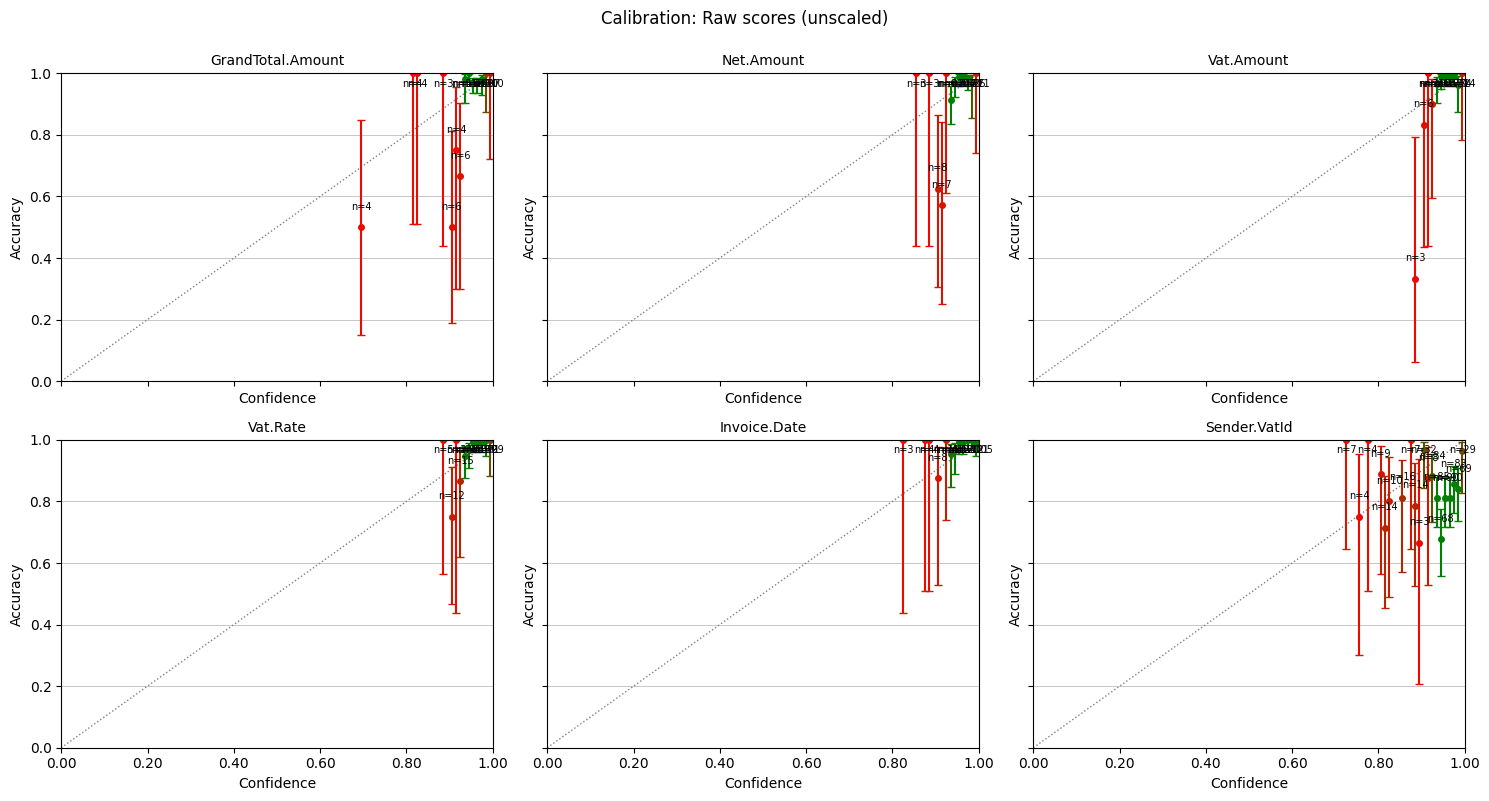

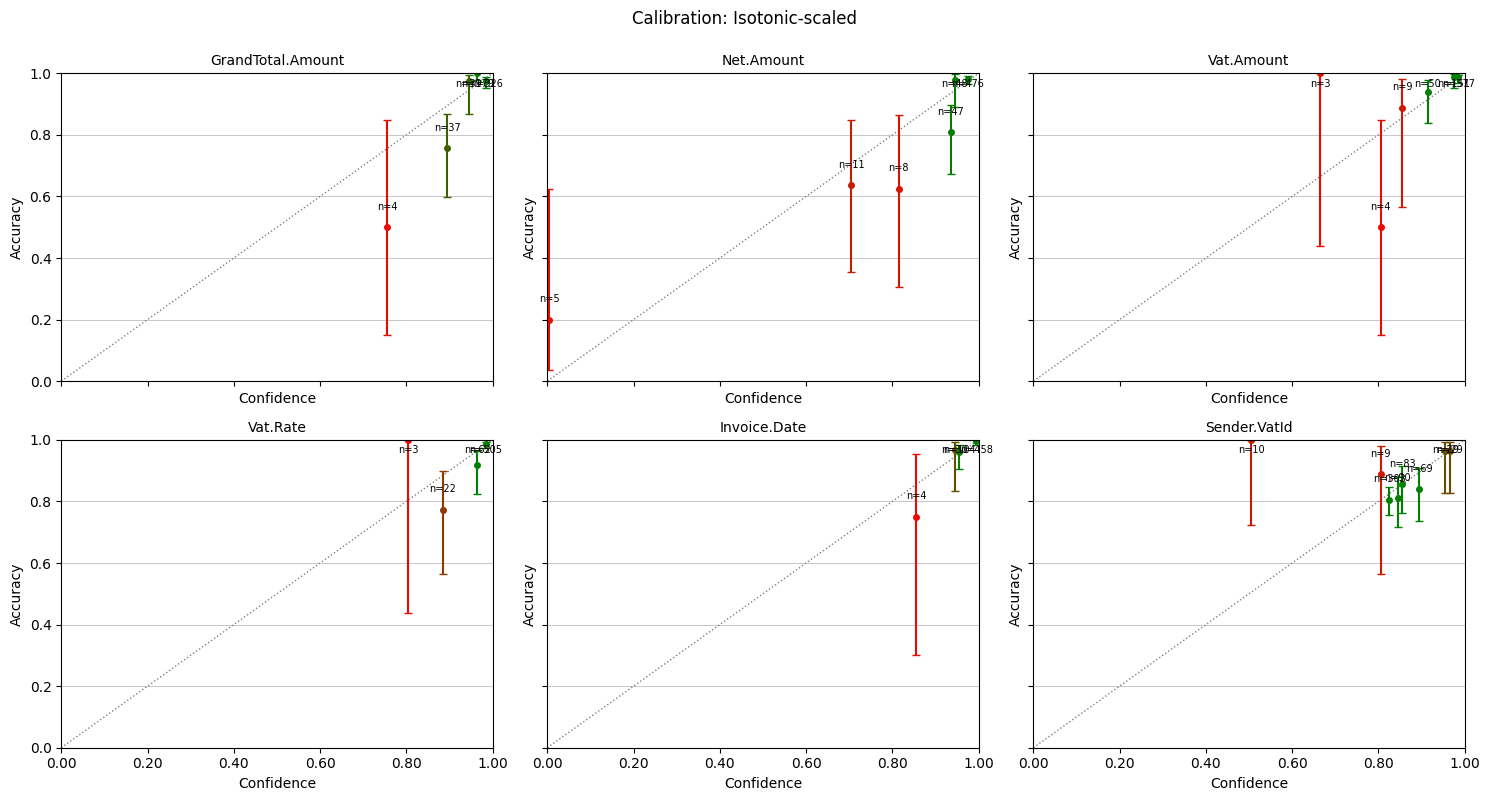

{'GrandTotal.Amount': array([(0.75, 0.76, 0.755,   4,   2, 0.5       , 0.15003571, 0.84996429),
        (0.89, 0.9 , 0.895,  37,  28, 0.75675676, 0.59882398, 0.86638797),
        (0.94, 0.95, 0.945,  39,  38, 0.97435897, 0.86818714, 0.99545941),
        (0.96, 0.97, 0.965, 179, 179, 1.        , 0.97898946, 1.        ),
        (0.98, 0.99, 0.985, 326, 318, 0.97546012, 0.95233099, 0.98751407)],
       dtype=[('bin_left', '<f8'), ('bin_right', '<f8'), ('bin_center', '<f8'), ('n', '<i4'), ('correct', '<i4'), ('accuracy', '<f8'), ('ci_low', '<f8'), ('ci_high', '<f8')]),
 'Net.Amount': array([(0.  , 0.01, 0.005,   5,   1, 0.2       , 0.03622316, 0.62447174),
        (0.7 , 0.71, 0.705,  11,   7, 0.63636364, 0.35379678, 0.84833776),
        (0.81, 0.82, 0.815,   8,   5, 0.625     , 0.30573785, 0.86315824),
        (0.93, 0.94, 0.935,  47,  38, 0.80851064, 0.6745572 , 0.89584184),
        (0.94, 0.95, 0.945,  48,  47, 0.97916667, 0.89100531, 0.99631298),
        (0.97, 0.98, 0.975, 476, 467, 

In [ ]:
# === Fixed + simplified: calibrated and raw plotted in TWO separate grids with identical styling ===

import json
import random
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
from sklearn.isotonic import IsotonicRegression as _Iso


# -----------------------------
# Core: load, split, fit models
# -----------------------------
def report_calibration_intervals_with_isotonic(
    run_dir: str | Path,
    mode: str = "consensus",
    test_size: float = 0.3,
    seed: int | None = 42,
    min_conf: float = 0.0,
    max_conf: float = 1.0,
    bin_width: float = 0.05,
    conf_level: float = 0.95,
    fields: list[str] | None = None,
):
    """
    Fit isotonic models on a training split and return fitted models + test split.
    """
    if fields is None:
        # fallback: expect NUMERIC_FIELDS defined upstream
        fields = [f for f in NUMERIC_FIELDS]

    # Load data
    if mode == "consensus":
        consensus_files = sorted(Path(run_dir).glob("*/consensus.json"))
        if not consensus_files:
            raise FileNotFoundError(f"No consensus.json files found in subdirectories of {run_dir}")

        samples_per_field = {}
        for field in fields:
            samples = []
            for consensus_file in consensus_files:
                try:
                    with open(consensus_file, "r", encoding="utf-8") as f:
                        consensus_data = json.load(f)
                    final_answer = consensus_data.get("final_answer", {}) or {}
                    for field_name, entry in final_answer.items():
                        if field_name == field and isinstance(entry, dict) and "avg_confidence" in entry:
                            conf = entry.get("avg_confidence", 0.0)
                            correct = entry.get("correct", None)
                            if correct is not None:
                                samples.append((float(conf), int(bool(correct))))
                except Exception:
                    continue
            samples_per_field[field] = samples

    else:
        run_files = list(Path(run_dir).rglob("*_grid_concat.json"))
        if not run_files:
            raise FileNotFoundError(f"No run files found in {run_dir}")

        samples_per_field = {}
        for field in fields:
            samples = []
            for run_file in run_files:
                try:
                    with open(run_file, "r", encoding="utf-8") as f:
                        run_data = json.load(f)
                    if (
                        field in run_data.get("answer", {})
                        and field in run_data.get("confidence_numeric", {})
                        and field in run_data.get("evaluation", {}).get("per_field", {})
                    ):
                        conf = run_data["confidence_numeric"][field]
                        correct = run_data["evaluation"]["per_field"][field][0]
                        if correct is not None:
                            samples.append((float(conf), int(bool(correct))))
                except Exception as e:
                    if "character maps to <undefined>" not in str(e):
                        print(f"Error processing {run_file}: {e}")
                    continue
            samples_per_field[field] = samples

    # Train/test split per field
    train_samples: Dict[str, List[Tuple[float, int]]] = {}
    test_samples: Dict[str, List[Tuple[float, int]]] = {}

    for field, samples in samples_per_field.items():
        if len(samples) < 10:
            print(f"Warning: Field {field} has only {len(samples)} samples, skipping")
            continue
        train_size = int(len(samples) * (1 - test_size))
        if seed is not None:
            random.seed(seed)
        random.shuffle(samples)
        train_samples[field] = samples[:train_size]
        test_samples[field] = samples[train_size:]

    # Fit isotonic models
    models: Dict[str, _Iso] = {}
    for field, samples in train_samples.items():
        if len(samples) < 5:
            continue
        scores = [s for s, _ in samples]
        labels = [l for _, l in samples]
        model = _Iso(out_of_bounds="clip")
        model.fit(scores, labels)
        models[field] = model

    return models, test_samples


# -----------------------------
# Binning + Wilson CI helpers
# -----------------------------
def _wilson_ci(p: float, n: int, z: float) -> Tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return max(0.0, center - margin), min(1.0, center + margin)


def _bin_ci_from_scores(
    scores: np.ndarray,
    labels: np.ndarray,
    *,
    min_conf: float,
    max_conf: float,
    bin_width: float,
    conf_level: float = 0.95,
    min_bin_n: int = 3,
):
    z = 1.96 if abs(conf_level - 0.95) < 1e-9 else (2.576 if abs(conf_level - 0.99) < 1e-9 else 1.96)
    bin_edges = np.arange(min_conf, max_conf + bin_width, bin_width)
    rows = []
    for left in bin_edges[:-1]:
        right = left + bin_width
        mask = (scores >= left) & (scores < right)
        n = int(mask.sum())
        if n < min_bin_n:
            continue
        correct = int(labels[mask].sum())
        acc = correct / n
        ci_low, ci_high = _wilson_ci(acc, n, z)
        rows.append((left, right, left + bin_width / 2, n, correct, acc, ci_low, ci_high))

    if not rows:
        return np.zeros(
            0,
            dtype=[
                ("bin_left", "f8"),
                ("bin_right", "f8"),
                ("bin_center", "f8"),
                ("n", "i4"),
                ("correct", "i4"),
                ("accuracy", "f8"),
                ("ci_low", "f8"),
                ("ci_high", "f8"),
            ],
        )
    return np.array(
        rows,
        dtype=[
            ("bin_left", "f8"),
            ("bin_right", "f8"),
            ("bin_center", "f8"),
            ("n", "i4"),
            ("correct", "i4"),
            ("accuracy", "f8"),
            ("ci_low", "f8"),
            ("ci_high", "f8"),
        ],
    )


def _bin_ci_from_models(
    models: Dict[str, _Iso],
    test_samples: Dict[str, List[Tuple[float, int]]],
    *,
    min_conf: float,
    max_conf: float,
    bin_width: float,
    conf_level: float = 0.95,
    min_bin_n: int = 3,
    fields: Optional[List[str]] = None,
) -> Dict[str, np.ndarray]:
    if fields is None:
        fields = list(models.keys())
    out: Dict[str, np.ndarray] = {}
    for field in fields:
        if field not in models or field not in test_samples:
            continue
        samples = test_samples[field]
        if not samples:
            continue
        raw_scores = np.array([s for s, _ in samples], dtype=float)
        labels = np.array([int(l) for _, l in samples], dtype=int)
        cal_scores = models[field].transform(raw_scores)
        out[field] = _bin_ci_from_scores(
            cal_scores,
            labels,
            min_conf=min_conf,
            max_conf=max_conf,
            bin_width=bin_width,
            conf_level=conf_level,
            min_bin_n=min_bin_n,
        )
    return out


def _bin_ci_from_test_samples_raw(
    test_samples: Dict[str, List[Tuple[float, int]]],
    *,
    min_conf: float,
    max_conf: float,
    bin_width: float,
    conf_level: float = 0.95,
    min_bin_n: int = 3,
    fields: Optional[List[str]] = None,
) -> Dict[str, np.ndarray]:
    if fields is None:
        fields = list(test_samples.keys())
    out: Dict[str, np.ndarray] = {}
    for field in fields:
        samples = test_samples.get(field, [])
        if not samples:
            continue
        scores = np.array([s for s, _ in samples], dtype=float)
        labels = np.array([int(l) for _, l in samples], dtype=int)
        out[field] = _bin_ci_from_scores(
            scores,
            labels,
            min_conf=min_conf,
            max_conf=max_conf,
            bin_width=bin_width,
            conf_level=conf_level,
            min_bin_n=min_bin_n,
        )
    return out


def _plot_grid_same_style(
    stats: Dict[str, np.ndarray],
    *,
    min_conf: float,
    max_conf: float,
    bin_width: float,
    title: Optional[str] = None,
    figsize=(15, 8),
    save_path=None,
    show=True,
    fields: Optional[List[str]] = None,
):
    if not stats:
        print("No valid stats to plot.")
        return

    order = fields or list(stats.keys())
    n_fields = len(order)
    cols = min(3, n_fields)
    rows = math.ceil(n_fields / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    cmap = mcolors.LinearSegmentedColormap.from_list("redgreen", ["red", "green"])

    for i, (ax, field) in enumerate(zip(axes, order)):
        arr = stats.get(field)
        if arr is None or arr.size == 0:
            ax.axis("off")
            continue

        x = arr["bin_center"].astype(float)
        y = np.clip(arr["accuracy"].astype(float), 0.0, 1.0)
        lo = np.clip(arr["ci_low"].astype(float), 0.0, 1.0)
        hi = np.clip(arr["ci_high"].astype(float), 0.0, 1.0)
        n = arr["n"].astype(int)

        m = np.isfinite(x) & np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
        x, y, lo, hi, n = x[m], y[m], lo[m], hi[m], n[m]
        if x.size == 0:
            ax.text(0.5, 0.5, "no bins", ha="center", va="center", transform=ax.transAxes)
            continue

        # reference diagonal
        xs = np.linspace(min_conf, max_conf, 100)
        ax.plot(xs, xs, linestyle=":", color="gray", linewidth=1)

        # per-point errorbars with colored markers and whiskers
        for xi, yi, loi, hii, ni in zip(x, y, lo, hi, n):
            col = (cmap(min(ni, 49) / 49.0) if ni < 50 else "green")
            yerr = np.array([[max(0.0, yi - loi)], [max(0.0, hii - yi)]])
            ax.errorbar(
                xi, yi, yerr=yerr,
                fmt="o", color=col, ecolor=col,
                elinewidth=1.5, capsize=3, markersize=4,
            )
            ax.text(xi, min(yi + 0.05, 0.95), f"n={ni}", ha="center", va="bottom", fontsize=7)

        ax.set_title(field, fontsize=10)
        ax.set_xlabel("Confidence")  # shown on all rows incl. top
        ax.set_ylabel("Accuracy")
        ax.set_xlim(min_conf, max_conf)
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", linewidth=0.5)
        ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))  # two decimals

    for ax in axes[n_fields:]:
        ax.axis("off")

    if title:
        fig.suptitle(title, y=0.995, fontsize=12)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)



def plot_calibration_ci_grid_calibrated(
    models, test_samples, *,
    min_conf=0.0, max_conf=1.0, bin_width=0.05,
    conf_level=0.95, min_bin_n=3, fields=None,
    figsize=(15, 8), save_path=None, show=True,
):
    stats_cal = _bin_ci_from_models(
        models=models,
        test_samples=test_samples,
        min_conf=min_conf,
        max_conf=max_conf,
        bin_width=bin_width,
        conf_level=conf_level,
        min_bin_n=min_bin_n,
        fields=fields,
    )
    _plot_grid_same_style(
        stats_cal,
        min_conf=min_conf,
        max_conf=max_conf,
        bin_width=bin_width,
        title="Calibration: Isotonic-scaled",
        figsize=figsize,
        save_path=save_path,
        show=show,
        fields=fields,
    )
    return stats_cal


def plot_calibration_ci_grid_raw(
    test_samples, *,
    min_conf=0.0, max_conf=1.0, bin_width=0.05,
    conf_level=0.95, min_bin_n=3, fields=None,
    figsize=(15, 8), save_path=None, show=True,
):
    stats_raw = _bin_ci_from_test_samples_raw(
        test_samples=test_samples,
        min_conf=min_conf,
        max_conf=max_conf,
        bin_width=bin_width,
        conf_level=conf_level,
        min_bin_n=min_bin_n,
        fields=fields,
        )
    _plot_grid_same_style(
        stats_raw,
        min_conf=min_conf,
        max_conf=max_conf,
        bin_width=bin_width,
        title="Calibration: Raw scores (unscaled)",
        figsize=figsize,
        save_path=save_path,
        show=show,
        fields=fields,
    )
    return stats_raw


MIN_CONF = 0.8

models, test_samples = report_calibration_intervals_with_isotonic(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="consensus",
    test_size=0.3,
    seed=1337,
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    conf_level=0.95,
    fields=["GrandTotal.Amount", "Net.Amount", "Vat.Amount", "Vat.Rate", "Invoice.Date", "Sender.VatId"],
)

# 1) Raw grid
plot_calibration_ci_grid_raw(
    test_samples=test_samples,
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    conf_level=0.95,
    save_path=Path("../Figures/calibration_raw.png"),
    show=True,
)

# 2) Calibrated grid
plot_calibration_ci_grid_calibrated(
    models=models,
    test_samples=test_samples,
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    conf_level=0.95,
    save_path=Path("../Figures/calibration_calibrated.png"),
    show=True,
)

In [ ]:
# Train/Test Isotonic Calibration Analysis
# This demonstrates how well isotonic calibration performs on unseen data

def analyze_holdout_calibration(run_dir: str | Path, mode: str = "runs", test_size: float = 0.3, seed: int = 42):
    """Analyze isotonic calibration performance on holdout test data."""
    run_dir = Path(run_dir)
    
    print(f"Analyzing holdout calibration for {mode} mode...")
    print(f"Test size: {test_size:.1%}, Seed: {seed}")
    print("="*60)
    
    # 1. Gather samples and split
    samples_raw = _gather_conf_label_samples(run_dir, mode)
    train_by_field, test_by_field = _train_test_split_per_field(samples_raw, test_size, seed)
    
    # 2. Fit models on training data
    models = _fit_isotonic_per_field(train_by_field)
    
    # 3. Apply calibration to test data
    calibrated_test = _apply_models(models, test_by_field)
    
    # 4. Evaluate performance
    metrics_before = evaluate_calibrated(test_by_field)
    metrics_after = evaluate_calibrated(calibrated_test)
    
    # 5. Print results
    print("Sample counts:")
    for field in COMPARE_FIELDS:
        train_count = len(train_by_field.get(field, []))
        test_count = len(test_by_field.get(field, []))
        print(f"  {field}: Train={train_count}, Test={test_count}")
    
    print("\nOverall metrics:")
    overall_before = metrics_before["overall"]
    overall_after = metrics_after["overall"]
    print(f"  ECE: {overall_before.get('ece', 0):.4f} → {overall_after.get('ece', 0):.4f}")
    print(f"  Brier: {overall_before.get('brier', 0):.4f} → {overall_after.get('brier', 0):.4f}")
    print(f"  AUROC: {overall_before.get('auroc', 0):.4f} → {overall_after.get('auroc', 0):.4f}")
    
    print("\nPer-field ECE improvements:")
    for field in COMPARE_FIELDS:
        before_ece = metrics_before["per_field"].get(field, {}).get("ece", 0)
        after_ece = metrics_after["per_field"].get(field, {}).get("ece", 0)
        improvement = before_ece - after_ece
        print(f"  {field}: {improvement:+.4f}")
    
    return {
        "metrics_before": metrics_before,
        "metrics_after": metrics_after,
        "models": models,
        "train_samples": train_by_field,
        "test_samples": test_by_field,
        "calibrated_test": calibrated_test
    }

# Run the analysis
results = analyze_holdout_calibration(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs",
    test_size=0.3,
    seed=42
)


Analyzing holdout calibration for runs mode...
Test size: 30.0%, Seed: 42
Sample counts:
  Sender.VatId: Train=4151, Test=1779
  GrandTotal.Amount: Train=4170, Test=1787
  Net.Amount: Train=4161, Test=1784
  Vat.Amount: Train=4157, Test=1782
  Vat.Rate: Train=4161, Test=1784
  Invoice.Date: Train=4168, Test=1786

Overall metrics:
  ECE: 0.0086 → 0.0089
  Brier: 0.0494 → 0.0475
  AUROC: 0.6676 → 0.7786

Per-field ECE improvements:
  Sender.VatId: +0.0821
  GrandTotal.Amount: +0.0188
  Net.Amount: +0.0140
  Vat.Amount: +0.0100
  Vat.Rate: +0.0052
  Invoice.Date: +0.0111


C:\Users\jonas\AppData\Local\Temp\ipykernel_2452\2564176300.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(tpr, fpr))


Running holdout calibration analysis for Prod-3-trace...
Gathering samples and performing train/test split...
Fitting isotonic models on training data...
Applying calibration to test data...
Evaluating calibration performance...


C:\Users\jonas\AppData\Local\Temp\ipykernel_2452\2564176300.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(tpr, fpr))


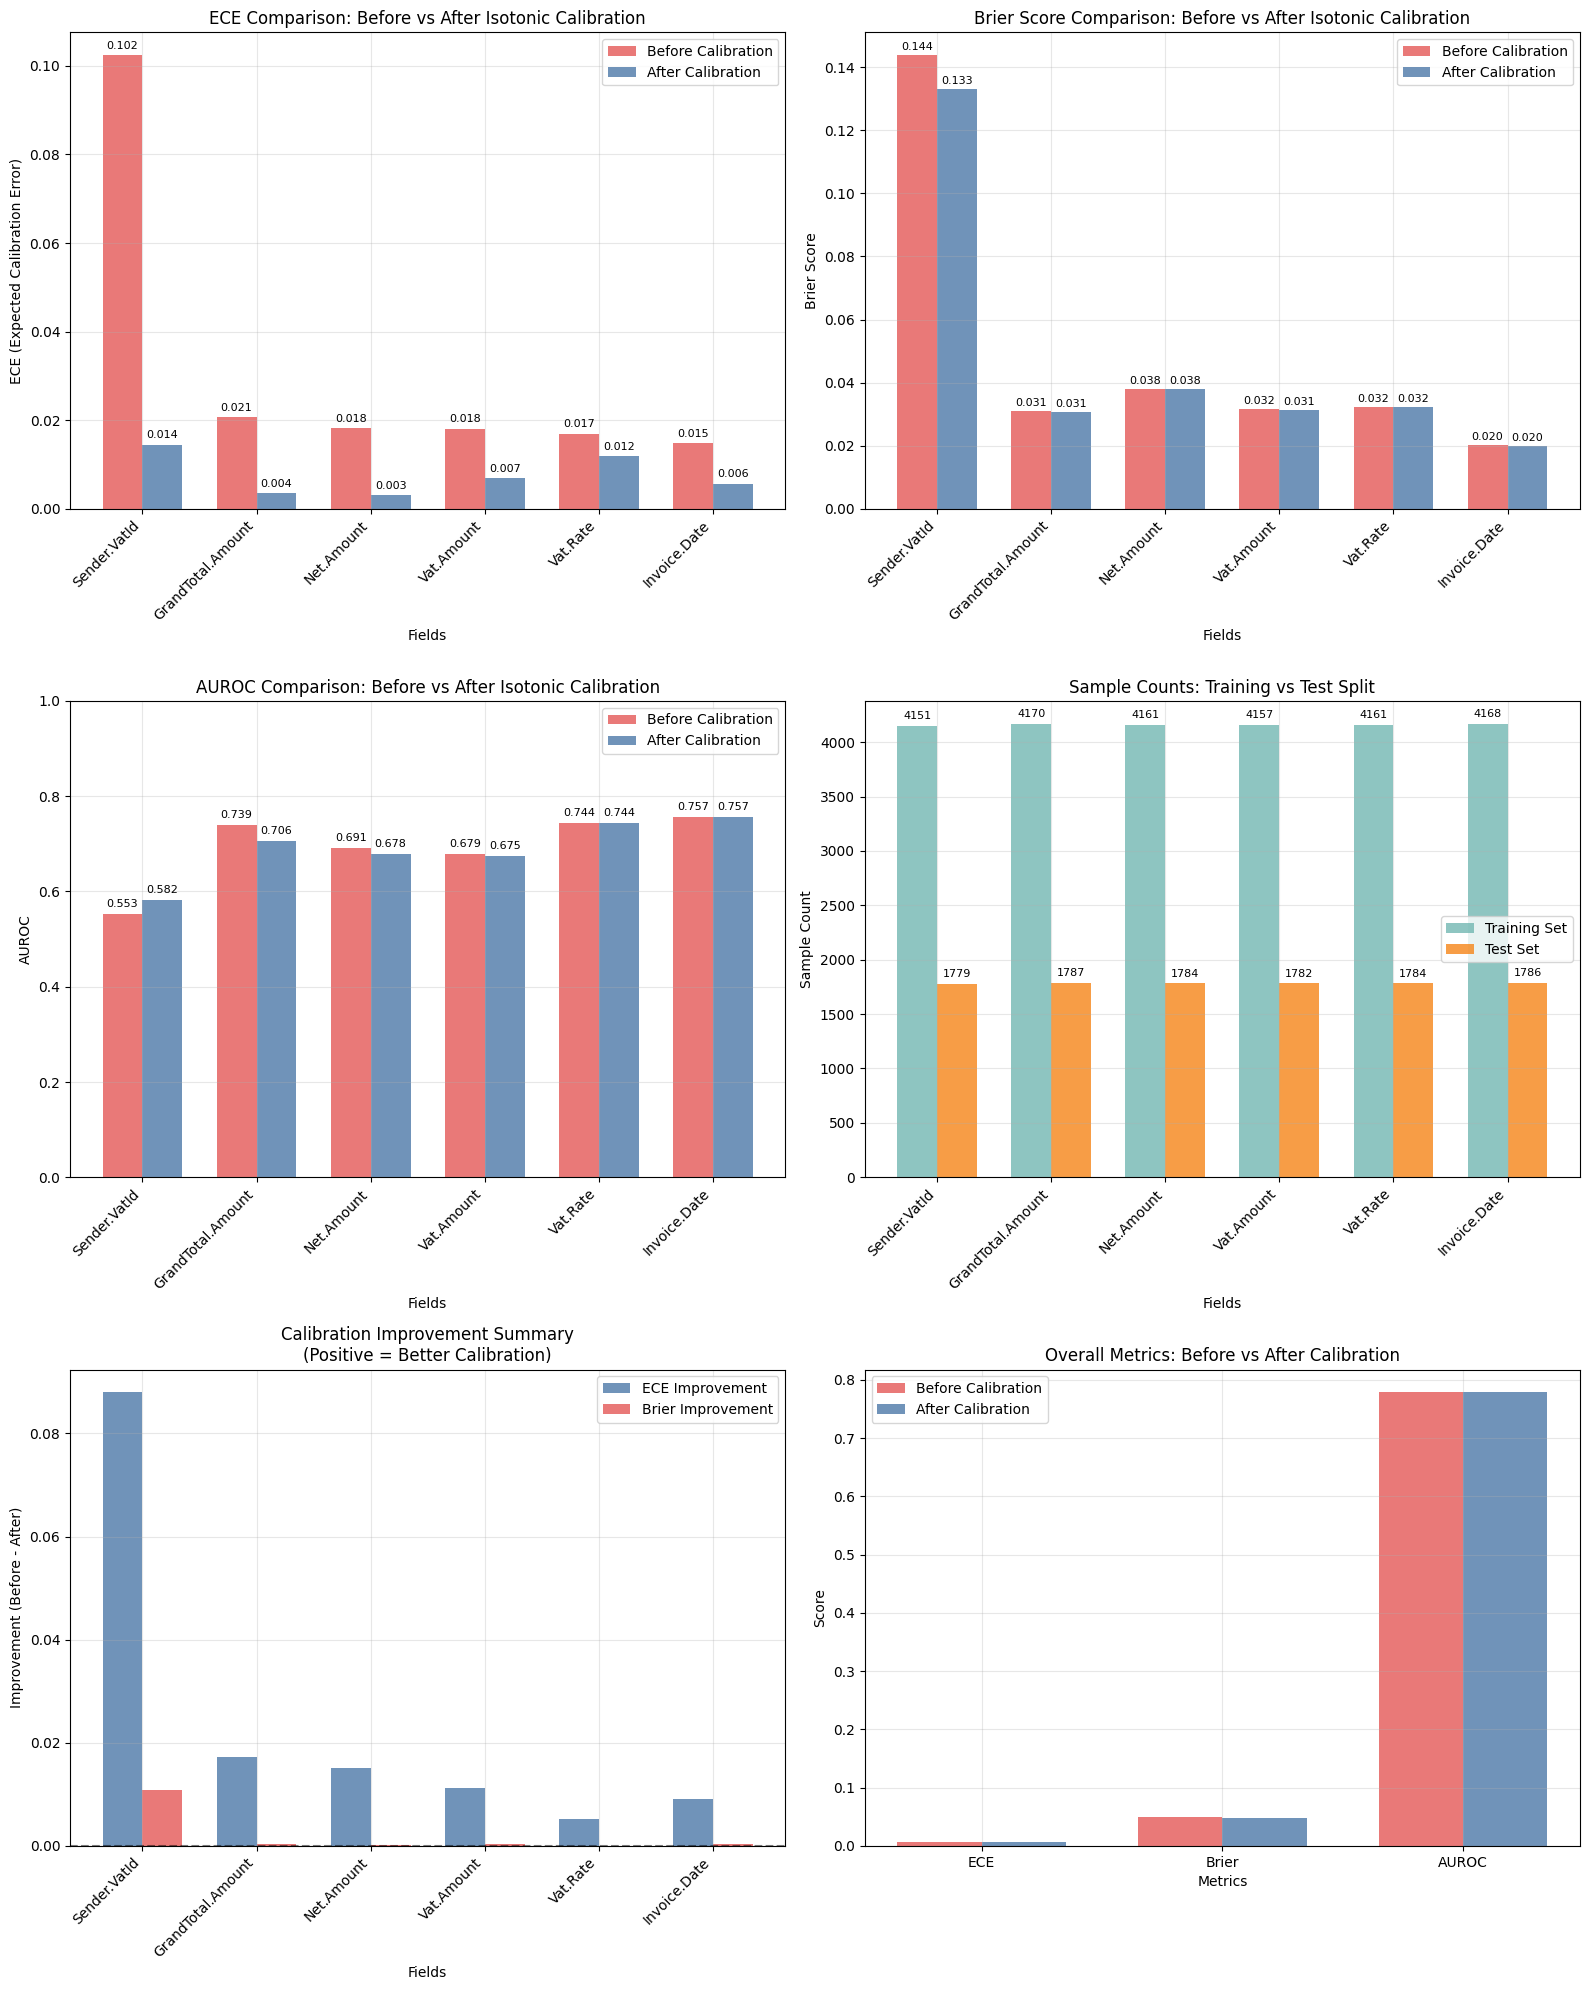

Saved: ..\Output\Prod-3-trace\holdout_calibration_analysis_runs_30pct.png

HOLDOUT CALIBRATION ANALYSIS SUMMARY
Mode: runs
Test Size: 30.0%
Seed: 42

Overall Metrics:
  ECE: 0.0074 → 0.0072 (Δ: -0.0002)
  Brier: 0.0494 → 0.0475 (Δ: -0.0020)
  AUROC: 0.6676 → 0.7786 (Δ: +0.1110)

Per-Field ECE Improvements:
  Sender.VatId: 0.1025 → 0.0145 (Δ: +0.0880)
  GrandTotal.Amount: 0.0207 → 0.0035 (Δ: +0.0172)
  Net.Amount: 0.0182 → 0.0031 (Δ: +0.0151)
  Vat.Amount: 0.0181 → 0.0069 (Δ: +0.0112)
  Vat.Rate: 0.0170 → 0.0118 (Δ: +0.0052)
  Invoice.Date: 0.0148 → 0.0056 (Δ: +0.0092)


In [ ]:
# Train/Test Isotonic Calibration Visualization
# This cell demonstrates how well isotonic calibration performs on unseen data

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

def visualize_holdout_calibration(
    run_dir: str | Path,
    mode: str = "runs",
    test_size: float = 0.3,
    seed: int = 42,
    min_conf: float = 0.0,
    max_conf: float = 1.0,
    bin_width: float = 0.01,
    min_bin_pct: float = 0.0
):
    """
    Visualize isotonic calibration performance on holdout test data.
    Shows before/after calibration comparison and calibration quality metrics.
    """
    run_dir = Path(run_dir)
    
    # 1. Gather raw samples and perform train/test split
    print("Gathering samples and performing train/test split...")
    samples_raw = _gather_conf_label_samples(run_dir, mode)
    
    # Split data
    train_by_field, test_by_field = _train_test_split_per_field(
        samples_raw, test_size=test_size, seed=seed
    )
    
    # 2. Fit isotonic models on training data
    print("Fitting isotonic models on training data...")
    models = _fit_isotonic_per_field(train_by_field)
    
    # 3. Apply calibration to test data
    print("Applying calibration to test data...")
    calibrated_test = _apply_models(models, test_by_field)
    
    # 4. Evaluate both raw and calibrated test data
    print("Evaluating calibration performance...")
    metrics_before = evaluate_calibrated(test_by_field, min_conf, max_conf, bin_width)
    metrics_after = evaluate_calibrated(calibrated_test, min_conf, max_conf, bin_width)
    
    # 5. Create comprehensive visualization
    fig, axes = plt.subplots(3, 2, figsize=(16, 20))
    
    # Plot 1: ECE Comparison (Before vs After)
    ax1 = axes[0, 0]
    fields = list(COMPARE_FIELDS)
    ece_before = [metrics_before["per_field"].get(f, {}).get("ece", 0) for f in fields]
    ece_after = [metrics_after["per_field"].get(f, {}).get("ece", 0) for f in fields]
    
    x = np.arange(len(fields))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, ece_before, width, label='Before Calibration', alpha=0.8, color='#E45756')
    bars2 = ax1.bar(x + width/2, ece_after, width, label='After Calibration', alpha=0.8, color='#4C78A8')
    
    ax1.set_xlabel('Fields')
    ax1.set_ylabel('ECE (Expected Calibration Error)')
    ax1.set_title('ECE Comparison: Before vs After Isotonic Calibration')
    ax1.set_xticks(x)
    ax1.set_xticklabels(fields, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Brier Score Comparison
    ax2 = axes[0, 1]
    brier_before = [metrics_before["per_field"].get(f, {}).get("brier", 0) for f in fields]
    brier_after = [metrics_after["per_field"].get(f, {}).get("brier", 0) for f in fields]
    
    bars3 = ax2.bar(x - width/2, brier_before, width, label='Before Calibration', alpha=0.8, color='#E45756')
    bars4 = ax2.bar(x + width/2, brier_after, width, label='After Calibration', alpha=0.8, color='#4C78A8')
    
    ax2.set_xlabel('Fields')
    ax2.set_ylabel('Brier Score')
    ax2.set_title('Brier Score Comparison: Before vs After Isotonic Calibration')
    ax2.set_xticks(x)
    ax2.set_xticklabels(fields, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars3:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars4:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 3: AUROC Comparison
    ax3 = axes[1, 0]
    auroc_before = [metrics_before["per_field"].get(f, {}).get("auroc", 0) for f in fields]
    auroc_after = [metrics_after["per_field"].get(f, {}).get("auroc", 0) for f in fields]
    
    bars5 = ax3.bar(x - width/2, auroc_before, width, label='Before Calibration', alpha=0.8, color='#E45756')
    bars6 = ax3.bar(x + width/2, auroc_after, width, label='After Calibration', alpha=0.8, color='#4C78A8')
    
    ax3.set_xlabel('Fields')
    ax3.set_ylabel('AUROC')
    ax3.set_title('AUROC Comparison: Before vs After Isotonic Calibration')
    ax3.set_xticks(x)
    ax3.set_xticklabels(fields, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)
    
    # Add value labels
    for bar in bars5:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars6:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 4: Sample Counts (Training vs Test)
    ax4 = axes[1, 1]
    train_counts = [len(train_by_field.get(f, [])) for f in fields]
    test_counts = [len(test_by_field.get(f, [])) for f in fields]
    
    bars7 = ax4.bar(x - width/2, train_counts, width, label='Training Set', alpha=0.8, color='#72B7B2')
    bars8 = ax4.bar(x + width/2, test_counts, width, label='Test Set', alpha=0.8, color='#F58518')
    
    ax4.set_xlabel('Fields')
    ax4.set_ylabel('Sample Count')
    ax4.set_title('Sample Counts: Training vs Test Split')
    ax4.set_xticks(x)
    ax4.set_xticklabels(fields, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Add value labels
    for bar in bars7:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + max(train_counts + test_counts) * 0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    for bar in bars8:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + max(train_counts + test_counts) * 0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    # Plot 5: Calibration Improvement Summary
    ax5 = axes[2, 0]
    ece_improvement = [b - a for b, a in zip(ece_before, ece_after)]
    brier_improvement = [b - a for b, a in zip(brier_before, brier_after)]
    
    x_pos = np.arange(len(fields))
    ax5.bar(x_pos - width/2, ece_improvement, width, label='ECE Improvement', alpha=0.8, color='#4C78A8')
    ax5.bar(x_pos + width/2, brier_improvement, width, label='Brier Improvement', alpha=0.8, color='#E45756')
    
    ax5.set_xlabel('Fields')
    ax5.set_ylabel('Improvement (Before - After)')
    ax5.set_title('Calibration Improvement Summary\n(Positive = Better Calibration)')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(fields, rotation=45, ha='right')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Plot 6: Overall Metrics Summary
    ax6 = axes[2, 1]
    overall_before = metrics_before["overall"]
    overall_after = metrics_after["overall"]
    
    metrics_names = ['ECE', 'Brier', 'AUROC']
    before_values = [
        overall_before.get("ece", 0),
        overall_before.get("brier", 0), 
        overall_after.get("auroc", 0)  # Note: AUROC improvement is after - before
    ]
    after_values = [
        overall_after.get("ece", 0),
        overall_after.get("brier", 0),
        overall_after.get("auroc", 0)
    ]
    
    x_metrics = np.arange(len(metrics_names))
    ax6.bar(x_metrics - width/2, before_values, width, label='Before Calibration', alpha=0.8, color='#E45756')
    ax6.bar(x_metrics + width/2, after_values, width, label='After Calibration', alpha=0.8, color='#4C78A8')
    
    ax6.set_xlabel('Metrics')
    ax6.set_ylabel('Score')
    ax6.set_title('Overall Metrics: Before vs After Calibration')
    ax6.set_xticks(x_metrics)
    ax6.set_xticklabels(metrics_names)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the plot
    output_path = run_dir / f"holdout_calibration_analysis_{mode}_{int(test_size*100)}pct.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_path}")
    
    # Print summary statistics
    print("\n" + "="*80)
    print("HOLDOUT CALIBRATION ANALYSIS SUMMARY")
    print("="*80)
    print(f"Mode: {mode}")
    print(f"Test Size: {test_size:.1%}")
    print(f"Seed: {seed}")
    print()
    
    print("Overall Metrics:")
    print(f"  ECE: {overall_before.get('ece', 0):.4f} → {overall_after.get('ece', 0):.4f} (Δ: {overall_after.get('ece', 0) - overall_before.get('ece', 0):+.4f})")
    print(f"  Brier: {overall_before.get('brier', 0):.4f} → {overall_after.get('brier', 0):.4f} (Δ: {overall_after.get('brier', 0) - overall_before.get('brier', 0):+.4f})")
    print(f"  AUROC: {overall_before.get('auroc', 0):.4f} → {overall_after.get('auroc', 0):.4f} (Δ: {overall_after.get('auroc', 0) - overall_before.get('auroc', 0):+.4f})")
    print()
    
    print("Per-Field ECE Improvements:")
    for field in fields:
        before_ece = metrics_before["per_field"].get(field, {}).get("ece", 0)
        after_ece = metrics_after["per_field"].get(field, {}).get("ece", 0)
        improvement = before_ece - after_ece
        print(f"  {field}: {before_ece:.4f} → {after_ece:.4f} (Δ: {improvement:+.4f})")
    
    return {
        "metrics_before": metrics_before,
        "metrics_after": metrics_after,
        "models": models,
        "train_samples": train_by_field,
        "test_samples": test_by_field,
        "calibrated_test": calibrated_test
    }

# Run the holdout calibration analysis
print(f"Running holdout calibration analysis for {FOLDER_TO_VISUALIZE}...")
results = visualize_holdout_calibration(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs",
    test_size=0.3,
    seed=42,
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    min_bin_pct=MIN_BIN_PCT
)


In [ ]:
import json
import math
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression as _Iso

from collections import Counter


def plot_calibration(
    run_dir: str | Path,
    mode: str = "consensus",
    min_conf: float = 0.90,
    max_conf: float = 1.00,
    bin_width: float = 0.01,
    min_bin_pct: float = 0.0,
    use_isotonic: bool = False,
    train_by_field: Optional[Dict[str, List[Tuple[float, int]]]] = None,
    test_by_field: Optional[Dict[str, List[Tuple[float, int]]]] = None,
):
    """Updated plot_calibration function that uses per-call train/test splits for isotonic scaling."""
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    # optional: restrict to test split if provided
    test_multisets = None
    if test_by_field is not None:
        test_multisets = {
            f: Counter(test_by_field.get(f, []))
            for f in COMPARE_FIELDS
        }

    # load source files
    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return

    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)
    
    # Fit isotonic models from provided train split if requested
    isotonic_models = {}
    if use_isotonic:
        assert train_by_field is not None, "train_by_field must be provided when use_isotonic=True"
        isotonic_models = _fit_isotonic_per_field(train_by_field)

    stats = defaultdict(lambda: [ {"correct": 0, "total": 0} for _ in range(num_bins) ])

    for f in files:
        try:
            data = json.loads(f.read_text(encoding="utf-8"))
        except Exception:
            continue

        if mode == "consensus":
            input_path = data.get("input_path")
            final_answer = data.get("final_answer", {}) or {}
            answer_values, per_field_conf = {}, {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    answer_values[field] = entry.get("value")
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    answer_values[field] = entry
                    per_field_conf[field] = None
            evaluation = compare_with_ground_truth(answer_values, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    is_match = bool(triple[0])
                except Exception:
                    continue
                
                conf = per_field_conf.get(field)
                if use_isotonic and conf is not None and field in isotonic_models:
                    model = isotonic_models[field]
                    if model is not None:
                        conf = model.predict([conf])[0]

                # filter to test split if provided
                if test_multisets is not None:
                    key = (conf, int(is_match))
                    if test_multisets.get(field, Counter()).get(key, 0) <= 0:
                        continue
                    test_multisets[field][key] -= 1

                idx = _bin_index_conf(conf, edges, minc, maxc, bw, num_bins)
                if idx is None:
                    continue
                stats[field][idx]["total"] += 1
                stats[field][idx]["correct"] += 1 if is_match else 0
        else:
            input_path = data.get("input_path")
            answer = data.get("answer", {}) or {}
            conf = data.get("confidence_numeric", {}) or {}
            evaluation = compare_with_ground_truth(answer, input_path)
            for field, triple in (evaluation.get("per_field", {}) or {}).items():
                try:
                    is_match = bool(triple[0])
                except Exception:
                    continue
                
                field_conf = conf.get(field)

                if use_isotonic and field_conf is not None and field in isotonic_models:
                    model = isotonic_models[field]
                    if model is not None:
                        field_conf = model.predict([field_conf])[0]

                # filter to test split if provided
                if test_multisets is not None:
                    key = (field_conf, int(is_match))
                    if test_multisets.get(field, Counter()).get(key, 0) <= 0:
                        continue
                    test_multisets[field][key] -= 1

                idx = _bin_index_conf(field_conf, edges, minc, maxc, bw, num_bins)
                if idx is None:
                    continue
                stats[field][idx]["total"] += 1
                stats[field][idx]["correct"] += 1 if is_match else 0

    for field in stats:
        for i in range(num_bins):
            if stats[field][i]['total'] > 0:
                print(f"Total fields for {field}: {stats[field][i]['total']}")
    fields_order = [f for f in COMPARE_FIELDS]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax_idx, field in enumerate(fields_order):
        ax = axes[ax_idx]
        bin_counts = stats.get(field, [ {"correct": 0, "total": 0} for _ in range(num_bins) ])
        x_pos = centers

        total_for_field = sum(c["total"] for c in bin_counts) or 1
        acc_pct = []
        x_conf, y_acc = [], []
        for i in range(num_bins):
            c = bin_counts[i]
            frac = (c["total"] / total_for_field)
            if c["total"] > 0 and frac > min_bin_pct:
                acc = 100.0 * c["correct"] / c["total"]
                acc_pct.append(acc)
                x_conf.append(float(x_pos[i]))
                y_acc.append(acc)
            else:
                acc_pct.append(np.nan)

        ax.bar(x_pos, acc_pct, width=bw * 0.9, color="#4C78A8", alpha=0.8, label="Bin accuracy")

        if len(x_conf) >= 2 and len(set(x_conf)) > 1:
            m, b0 = np.polyfit(np.array(x_conf), np.array(y_acc), 1)
            x_line = np.linspace(minc, maxc, 100)
            y_line = m * x_line + b0
            ax.plot(x_line, y_line, color="#E45756", linewidth=2, label="Linear fit")

            r = float(np.corrcoef(np.array(x_conf), np.array(y_acc))[0, 1])
            txt = f"y = {m:.2f}x + {b0:.2f}\nr = {r:.3f}"
            ax.text(
                minc + 0.01 * (maxc - minc),
                96,
                txt,
                va="top",
                ha="left",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=3),
            )

        x_ref = np.linspace(minc, maxc, 100)
        y_ref = 100.0 * x_ref
        ax.plot(x_ref, y_ref, color="#72B7B2", linestyle="--", linewidth=1.5, label="Ideal")

        ax.set_ylim(0, 100)
        ax.set_title(field)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx % 3 == 0:
            ax.set_ylabel("Accuracy (%)")
        if ax_idx >= 3:
            ax.set_xlabel(f"Confidence ({int(bw*100)}% bins)")

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    mode_txt = "consensus" if mode == "consensus" else "individual runs"
    isotonic_txt = " (with isotonic scaling)" if use_isotonic else ""
    fig.suptitle(
        f"Calibration ({mode_txt}){isotonic_txt} — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f} | cutoff>{int(min_bin_pct*100)}%"
    )
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])

    suffix = "consensus" if mode == "consensus" else "runs"
    isotonic_suffix = "_isotonic" if use_isotonic else ""
    out_path = run_dir / f"calibration_{suffix}{isotonic_suffix}_grid_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct_cut{int(min_bin_pct*100)}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")


def _make_bins(min_conf: float = 0.90, max_conf: float = 1.00, bin_width: float = 0.01):
    min_conf = float(min_conf); max_conf = float(max_conf); bin_width = float(bin_width)
    assert 0.0 <= min_conf < max_conf <= 1.0, "Range must be within [0,1] and min<max"
    assert bin_width > 0, "bin_width must be > 0"
    # Left edges; ensure we include max bin by not stepping past max_conf
    edges = np.arange(min_conf, max_conf, bin_width)
    # If max_conf is exactly on a step, last edge < max_conf; we want last bin to include max_conf
    num_bins = len(edges)
    centers = edges + bin_width / 2.0
    # Clip the last center to max_conf if it goes beyond
    if centers.size > 0:
        centers[-1] = min(centers[-1], max_conf)
    labels = [f"{c:.2f}" for c in centers]
    # If the last bin should explicitly read max_conf (e.g., 1.00), set label
    if labels:
        labels[-1] = f"{max_conf:.2f}"
    return edges, centers, labels, num_bins, bin_width, min_conf, max_conf

def _bin_index_conf(c: float, edges: np.ndarray, min_conf: float, max_conf: float, bin_width: float, num_bins: int):
    if c is None:
        return None
    c = max(0.0, min(1.0, float(c)))
    if c < min_conf:
        return None
    if c >= max_conf:
        return num_bins - 1  # include max_conf in the last bin
    return int(math.floor((c - min_conf) / bin_width))

def plot_confidence_frequency(
    run_dir: str | Path,
    mode: str = "consensus",
    min_conf: float = 0.90,
    max_conf: float = 1.00,
    bin_width: float = 0.01,
    train_by_field: Optional[Dict[str, List[Tuple[float, int]]]] = None,
    test_by_field: Optional[Dict[str, List[Tuple[float, int]]]] = None,
):
    run_dir = Path(run_dir)
    assert run_dir.is_dir(), f"Not a directory: {run_dir}"
    assert mode in ("consensus", "runs"), "mode must be 'consensus' or 'runs'"

    # optional: restrict to test split if provided (by confidence only)
    test_multisets = None
    if test_by_field is not None:
        test_multisets = {
            f: Counter([c for (c, _y) in test_by_field.get(f, [])])
            for f in COMPARE_FIELDS
        }

    # select files
    if mode == "consensus":
        files = sorted(run_dir.glob("*/consensus.json"))
        assert files, f"No consensus.json files under {run_dir}"
    else:
        files = sorted(run_dir.glob("*/*/*.json"))
        if not files:
            print(f"No individual run files under {run_dir}")
            return

    edges, centers, labels, num_bins, bw, minc, maxc = _make_bins(min_conf, max_conf, bin_width)
    freq = defaultdict(lambda: [0 for _ in range(num_bins)])

    for f in files:
        try:
            data = json.loads(f.read_text(encoding="utf-8"))
        except Exception:
            continue

        if mode == "consensus":
            final_answer = data.get("final_answer", {}) or {}
            per_field_conf = {}
            for field, entry in final_answer.items():
                if isinstance(entry, dict) and "value" in entry:
                    per_field_conf[field] = entry.get("avg_confidence")
                else:
                    per_field_conf[field] = None
            for field, c in per_field_conf.items():
                # filter to test split if provided
                if test_multisets is not None:
                    if test_multisets.get(field, Counter()).get(c, 0) <= 0:
                        continue
                    test_multisets[field][c] -= 1
                idx = _bin_index_conf(c, edges, minc, maxc, bw, num_bins)
                if idx is not None:
                    freq[field][idx] += 1
        else:
            conf = data.get("confidence_numeric", {}) or {}
            for field, c in conf.items():
                # filter to test split if provided
                if test_multisets is not None:
                    if test_multisets.get(field, Counter()).get(c, 0) <= 0:
                        continue
                    test_multisets[field][c] -= 1
                idx = _bin_index_conf(c, edges, minc, maxc, bw, num_bins)
                if idx is not None:
                    freq[field][idx] += 1

    fields_order = [f for f in COMPARE_FIELDS]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax_idx, field in enumerate(fields_order):
        ax = axes[ax_idx]
        counts = freq.get(field, [0 for _ in range(num_bins)])
        ax.bar(centers, counts, width=bw * 0.9, color="#4C78A8", alpha=0.85, label="Frequency")
        ax.set_title(field)
        ax.set_ylabel("Count")
        tick_step = 0.05
        xt = np.arange(minc, maxc + 1e-9, tick_step)
        xlbl = [f"{t:.2f}" for t in xt]
        ax.set_xticks(xt, xlbl)
        if ax_idx >= 3:
            ax.set_xlabel(f"Confidence ({int(bw*100)}% bins)")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3)
    mode_txt = "consensus" if mode == "consensus" else "individual runs"
    fig.suptitle(f"Confidence frequency ({mode_txt}) — bins {int(bw*100)}% from {minc:.2f} to {maxc:.2f}")
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])

    suffix = "consensus" if mode == "consensus" else "runs"
    out_path = run_dir / f"frequency_{suffix}_grid_{int(minc*100)}_{int(maxc*100)}_{int(bw*100)}pct.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")


Confidence Score Distribution Analysis
(with Isotonic Scaling)
Applying isotonic scaling...
Fitted isotonic models for 6 fields

GrandTotal.Amount (Raw):
  Total samples: 5957
  Unique confidence levels: 26
  Confidence range: 0.000 - 1.000
  Sample count range: 1 - 3605
  Pearson correlation: r=0.281, p=0.165
  Spearman correlation: ρ=0.687, p=0.000
  Top confidence levels by sample count:
    0.95: 3605 samples
    0.98: 1120 samples
    0.99: 568 samples
    0.90: 366 samples
    0.97: 56 samples

Net.Amount (Raw):
  Total samples: 5945
  Unique confidence levels: 25
  Confidence range: 0.000 - 1.000
  Sample count range: 1 - 2685
  Pearson correlation: r=0.347, p=0.089
  Spearman correlation: ρ=0.791, p=0.000
  Top confidence levels by sample count:
    0.95: 2685 samples
    0.98: 1135 samples
    0.99: 595 samples
    0.90: 465 samples
    0.96: 371 samples

Vat.Amount (Raw):
  Total samples: 5939
  Unique confidence levels: 26
  Confidence range: 0.000 - 1.000
  Sample count ran

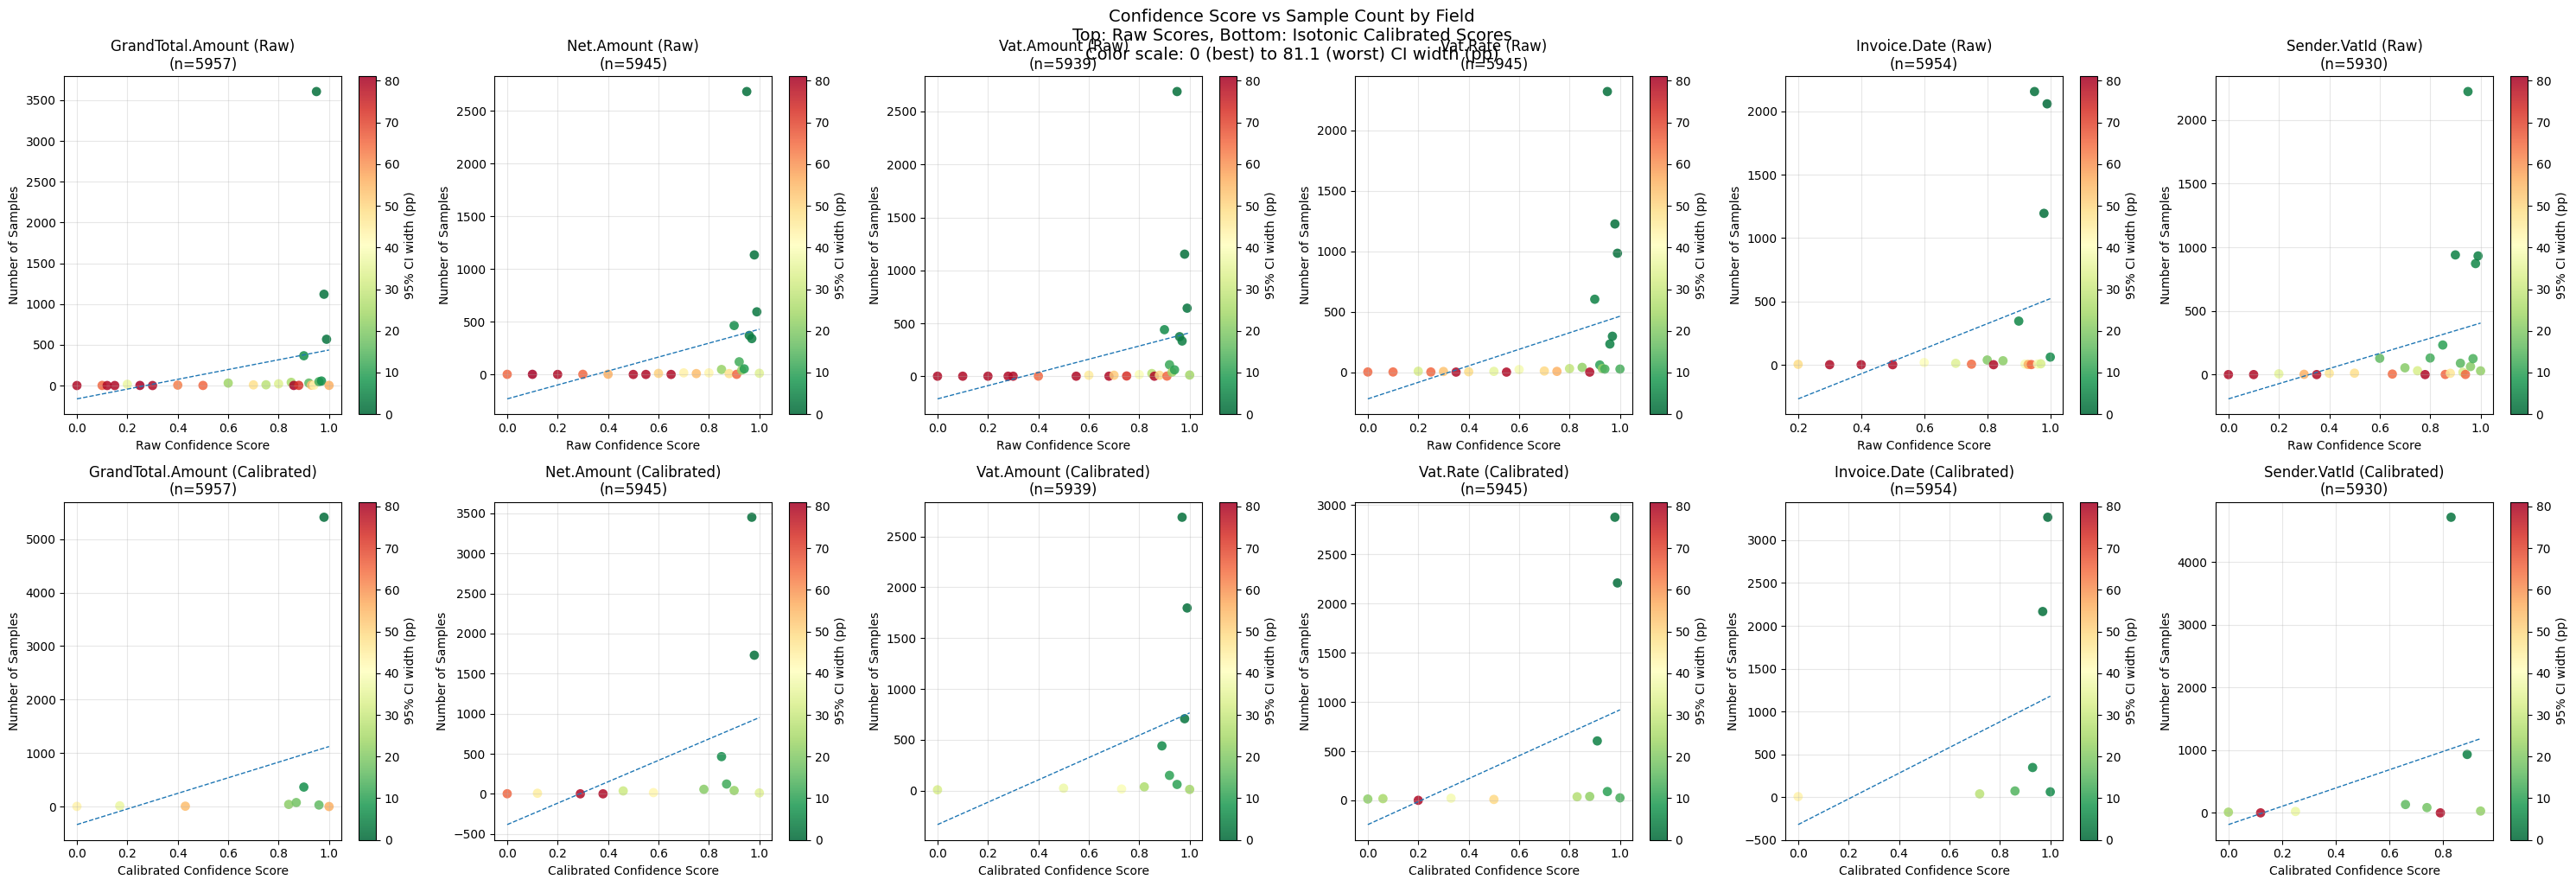

In [ ]:
# Confidence score vs sample count, colored by 95% CI width (percentage points)
import json
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

def _wilson_ci(k: int, n: int, z: float = 1.96):
    if n == 0:
        return np.nan, np.nan
    phat = k / n
    denom = 1.0 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, center - half), min(1.0, center + half)

def analyze_confidence_sample_correlation(
    run_dir: str | Path, 
    fields: list[str] = None,
    use_isotonic: bool = False,
    test_size: float = 0.3,
    seed: int | None = 42,
    train_by_field: dict | None = None,
    test_by_field: dict | None = None,
):
    """
    Correlate confidence scores with sample counts and color points by 95% Wilson CI width (pp)
    for accuracy at each confidence level. Optionally apply isotonic scaling to calibrate confidence scores.

    If train_by_field and test_by_field are provided, they are used for fitting (train) and
    can be kept for downstream evaluation. Otherwise a per-field split is created.
    """
    if fields is None:
        fields = ["GrandTotal.Amount", "Net.Amount", "Vat.Amount", "Vat.Rate", "Invoice.Date", "Sender.VatId"]
    
    run_files = list(Path(run_dir).rglob("*_grid_concat.json"))
    all_confidence_data = []
    
    for run_file in run_files:
        try:
            with open(run_file, 'r', encoding='utf-8') as f:
                run_data = json.load(f)
            
            for field in fields:
                if (field in run_data.get('answer', {}) and 
                    field in run_data.get('confidence_numeric', {}) and
                    field in run_data.get('evaluation', {}).get('per_field', {})):
                    
                    conf = run_data['confidence_numeric'][field]
                    correct = run_data['evaluation']['per_field'][field][0]  # 1/0 correctness
                    all_confidence_data.append({
                        'field': field,
                        'confidence': conf,
                        'correct': correct,
                        'file': str(run_file)
                    })
        except Exception as e:
            print(f"Error processing {run_file}: {e}")
            continue
    
    df = pd.DataFrame(all_confidence_data)
    print("Confidence Score Distribution Analysis")
    if use_isotonic:
        print("(with Isotonic Scaling)")
    print("=" * 60)
    
    isotonic_models = {}
    calibrated_df = None
    
    if use_isotonic:
        print("Applying isotonic scaling...")
        
        # Build samples from the full dataframe (used for visualization after fitting)
        samples_by_field = {}
        for field in fields:
            field_data = df[df['field'] == field]
            if len(field_data) > 0:
                samples = [(row['confidence'], row['correct']) for _, row in field_data.iterrows()]
                samples_by_field[field] = samples
        
        # Use provided split if given; otherwise create one
        if train_by_field is None or test_by_field is None:
            train_by_field, test_by_field = _train_test_split_per_field(
                samples_by_field, test_size=test_size, seed=seed
            )
        
        # Fit isotonic on training data
        isotonic_models = _fit_isotonic_per_field(train_by_field)
        
        # Apply calibration to all data (for visualization)
        calibrated_samples = _apply_models(isotonic_models, samples_by_field)
        
        calibrated_data = []
        for field, samples in calibrated_samples.items():
            for conf, correct in samples:
                calibrated_data.append({
                    'field': field,
                    'confidence': conf,
                    'correct': correct,
                    'file': 'calibrated'
                })
        calibrated_df = pd.DataFrame(calibrated_data)
        
        print(f"Fitted isotonic models for {len([m for m in isotonic_models.values() if m is not None])} fields")
    
    # Analysis for raw confidence scores
    correlation_results = {}
    per_field_bins = {}
    
    for field in fields:
        field_data = df[df['field'] == field]
        if len(field_data) == 0:
            continue
            
        field_data = field_data.copy()
        field_data['confidence_rounded'] = field_data['confidence'].round(2)
        
        agg = (field_data
               .groupby('confidence_rounded', as_index=False)
               .agg(n=('correct', 'size'),
                    k=('correct', 'sum')))
        agg['acc'] = agg['k'] / agg['n']
        ci = np.array([_wilson_ci(int(k), int(n)) for k, n in zip(agg['k'], agg['n'])])
        agg['ci_lo'] = ci[:, 0]
        agg['ci_hi'] = ci[:, 1]
        agg['ci_width_pp'] = (agg['ci_hi'] - agg['ci_lo']) * 100.0
        
        per_field_bins[field] = agg.copy()
        
        if len(agg) > 1:
            pearson_r, pearson_p = pearsonr(agg['confidence_rounded'].values, agg['n'].values)
            spearman_r, spearman_p = spearmanr(agg['confidence_rounded'].values, agg['n'].values)
            correlation_results[field] = {
                'pearson_r': float(pearson_r),
                'pearson_p': float(pearson_p),
                'spearman_r': float(spearman_r),
                'spearman_p': float(spearman_p),
                'n_confidence_levels': int(len(agg)),
                'total_samples': int(len(field_data))
            }
            print(f"\n{field} (Raw):")
            print(f"  Total samples: {len(field_data)}")
            print(f"  Unique confidence levels: {len(agg)}")
            print(f"  Confidence range: {agg['confidence_rounded'].min():.3f} - {agg['confidence_rounded'].max():.3f}")
            print(f"  Sample count range: {agg['n'].min()} - {agg['n'].max()}")
            print(f"  Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.3f}")
            print(f"  Spearman correlation: ρ={spearman_r:.3f}, p={spearman_p:.3f}")
            top_levels = agg.sort_values('n', ascending=False).head(5)
            print(f"  Top confidence levels by sample count:")
            for _, row in top_levels.iterrows():
                print(f"    {row['confidence_rounded']:.2f}: {int(row['n'])} samples")
    
    # Calibrated analysis
    calibrated_correlation_results = {}
    calibrated_per_field_bins = {}
    
    if use_isotonic and calibrated_df is not None:
        print("\n" + "="*60)
        print("Calibrated Confidence Score Analysis")
        print("="*60)
        
        for field in fields:
            field_data = calibrated_df[calibrated_df['field'] == field]
            if len(field_data) == 0:
                continue
                
            field_data = field_data.copy()
            field_data['confidence_rounded'] = field_data['confidence'].round(2)
            
            agg = (field_data
                   .groupby('confidence_rounded', as_index=False)
                   .agg(n=('correct', 'size'),
                        k=('correct', 'sum')))
            agg['acc'] = agg['k'] / agg['n']
            ci = np.array([_wilson_ci(int(k), int(n)) for k, n in zip(agg['k'], agg['n'])])
            agg['ci_lo'] = ci[:, 0]
            agg['ci_hi'] = ci[:, 1]
            agg['ci_width_pp'] = (agg['ci_hi'] - agg['ci_lo']) * 100.0
            
            calibrated_per_field_bins[field] = agg.copy()
            
            if len(agg) > 1:
                pearson_r, pearson_p = pearsonr(agg['confidence_rounded'].values, agg['n'].values)
                spearman_r, spearman_p = spearmanr(agg['confidence_rounded'].values, agg['n'].values)
                calibrated_correlation_results[field] = {
                    'pearson_r': float(pearson_r),
                    'pearson_p': float(pearson_p),
                    'spearman_r': float(spearman_r),
                    'spearman_p': float(spearman_p),
                    'n_confidence_levels': int(len(agg)),
                    'total_samples': int(len(field_data))
                }
                print(f"\n{field} (Calibrated):")
                print(f"  Total samples: {len(field_data)}")
                print(f"  Unique confidence levels: {len(agg)}")
                print(f"  Confidence range: {agg['confidence_rounded'].min():.3f} - {agg['confidence_rounded'].max():.3f}")
                print(f"  Sample count range: {agg['n'].min()} - {agg['n'].max()}")
                print(f"  Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.3f}")
                print(f"  Spearman correlation: ρ={spearman_r:.3f}, p={spearman_p:.3f}")
                top_levels = agg.sort_values('n', ascending=False).head(5)
                print(f"  Top confidence levels by sample count:")
                for _, row in top_levels.iterrows():
                    print(f"    {row['confidence_rounded']:.2f}: {int(row['n'])} samples")
    
    # Color scale bounds
    if use_isotonic and calibrated_df is not None:
        all_ci_values = []
        for field in fields:
            if field in per_field_bins and len(per_field_bins[field]) > 0:
                all_ci_values.extend(per_field_bins[field]['ci_width_pp'].values)
            if field in calibrated_per_field_bins and len(calibrated_per_field_bins[field]) > 0:
                all_ci_values.extend(calibrated_per_field_bins[field]['ci_width_pp'].values)
    else:
        all_ci_values = []
        for field in fields:
            if field in per_field_bins and len(per_field_bins[field]) > 0:
                all_ci_values.extend(per_field_bins[field]['ci_width_pp'].values)

    vmin = 0.0
    vmax = max(all_ci_values) if all_ci_values else 100.0

    # Visualization (unchanged logic, uses vmax from above)
    if use_isotonic and calibrated_df is not None:
        fig, axes = plt.subplots(2, 6, figsize=(30, 10))
        for i, field in enumerate(fields):
            if i >= 6:
                break
            field_data = df[df['field'] == field]
            if len(field_data) == 0:
                axes[0, i].set_visible(False)
                continue
            agg = per_field_bins[field]
            x = agg['confidence_rounded'].values
            y = agg['n'].values
            c = agg['ci_width_pp'].values
            sc = axes[0, i].scatter(x, y, c=c, cmap='RdYlGn_r', s=60, alpha=0.85, edgecolors='none', vmin=vmin, vmax=vmax)            
            axes[0, i].set_xlabel('Raw Confidence Score')
            axes[0, i].set_ylabel('Number of Samples')
            axes[0, i].set_title(f'{field} (Raw)\n(n={len(field_data)})')
            axes[0, i].grid(True, alpha=0.3)
            if len(agg) > 1:
                z = np.polyfit(x, y, 1); p = np.poly1d(z)
                axes[0, i].plot(x, p(x), linestyle="--", linewidth=1)
            cb = plt.colorbar(sc, ax=axes[0, i]); cb.set_label('95% CI width (pp)')
        for i, field in enumerate(fields):
            if i >= 6:
                break
            field_data = calibrated_df[calibrated_df['field'] == field]
            if len(field_data) == 0:
                axes[1, i].set_visible(False)
                continue
            agg = calibrated_per_field_bins[field]
            x = agg['confidence_rounded'].values
            y = agg['n'].values
            c = agg['ci_width_pp'].values
            sc = axes[1, i].scatter(x, y, c=c, cmap='RdYlGn_r', s=60, alpha=0.85, edgecolors='none', vmin=vmin, vmax=vmax)            
            axes[1, i].set_xlabel('Calibrated Confidence Score')
            axes[1, i].set_ylabel('Number of Samples')
            axes[1, i].set_title(f'{field} (Calibrated)\n(n={len(field_data)})')
            axes[1, i].grid(True, alpha=0.3)
            if len(agg) > 1:
                z = np.polyfit(x, y, 1); p = np.poly1d(z)
                axes[1, i].plot(x, p(x), linestyle="--", linewidth=1)
            cb = plt.colorbar(sc, ax=axes[1, i]); cb.set_label('95% CI width (pp)')
        for i in range(len(fields), 6):
            axes[0, i].set_visible(False); axes[1, i].set_visible(False)
        plt.tight_layout()
        plt.suptitle(f'Confidence Score vs Sample Count by Field\nTop: Raw Scores, Bottom: Isotonic Calibrated Scores\nColor scale: 0 (best) to {vmax:.1f} (worst) CI width (pp)', y=1.02, fontsize=14)
        plt.show()
    else:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for i, field in enumerate(fields):
            if i >= len(axes):
                break
            field_data = df[df['field'] == field]
            if len(field_data) == 0:
                axes[i].set_visible(False)
                continue
            agg = per_field_bins[field]
            x = agg['confidence_rounded'].values
            y = agg['n'].values
            c = agg['ci_width_pp'].values
            sc = axes[i].scatter(x, y, c=c, cmap='RdYlGn_r', s=60, alpha=0.85, edgecolors='none', vmin=vmin, vmax=vmax)            
            axes[i].set_xlabel('Raw Confidence Score')
            axes[i].set_ylabel('Number of Samples')
            axes[i].set_title(f'{field}\n(n={len(field_data)})')
            axes[i].grid(True, alpha=0.3)
            if len(agg) > 1:
                z = np.polyfit(x, y, 1); p = np.poly1d(z)
                axes[i].plot(x, p(x), linestyle="--", linewidth=1)
            cb = plt.colorbar(sc, ax=axes[i]); cb.set_label('95% CI width (percentage points)')
        for i in range(len(fields), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        plt.suptitle(f'Confidence Score vs Sample Count by Field\nColor = 95% CI width (pp, Wilson)\nColor scale: 0 (best) to {vmax:.1f} (worst)', y=1.02, fontsize=14)
        plt.show()
    
    results = {
        'raw_correlation_results': correlation_results,
        'raw_df': df,
        'raw_per_field_bins': per_field_bins,
        'use_isotonic': use_isotonic
    }
    if use_isotonic:
        results.update({
            "train_by_field": train_by_field,
            "test_by_field": test_by_field,
            'isotonic_models': isotonic_models,
            'calibrated_correlation_results': calibrated_correlation_results,
            'calibrated_df': calibrated_df,
            'calibrated_per_field_bins': calibrated_per_field_bins,
            'train_by_field': train_by_field,
            'test_by_field': test_by_field,
        })
    return results

# Run the analysis with isotonic scaling
results = analyze_confidence_sample_correlation(
    run_dir=f"../Output/{FOLDER_TO_VISUALIZE}",
    fields=["GrandTotal.Amount", "Net.Amount", "Vat.Amount", "Vat.Rate", "Invoice.Date", "Sender.VatId"],
    use_isotonic=True,
    test_size=0.3,
    seed=42
)

train_by_field = results["train_by_field"]
test_by_field = results["test_by_field"]

# Access the results
correlation_results = results['raw_correlation_results']
confidence_df = results['raw_df']
calibrated_df = results.get('calibrated_df')
isotonic_models = results.get('isotonic_models')


Total fields for Net.Amount: 42
Total fields for Net.Amount: 4
Total fields for Vat.Rate: 5
Total fields for Invoice.Date: 18
Total fields for GrandTotal.Amount: 9
Total fields for GrandTotal.Amount: 1
Total fields for Vat.Amount: 61
Total fields for Vat.Amount: 3


c:\Users\jonas\Desktop\LLM-Confidence\Code\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jonas\Desktop\LLM-Confidence\Code\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


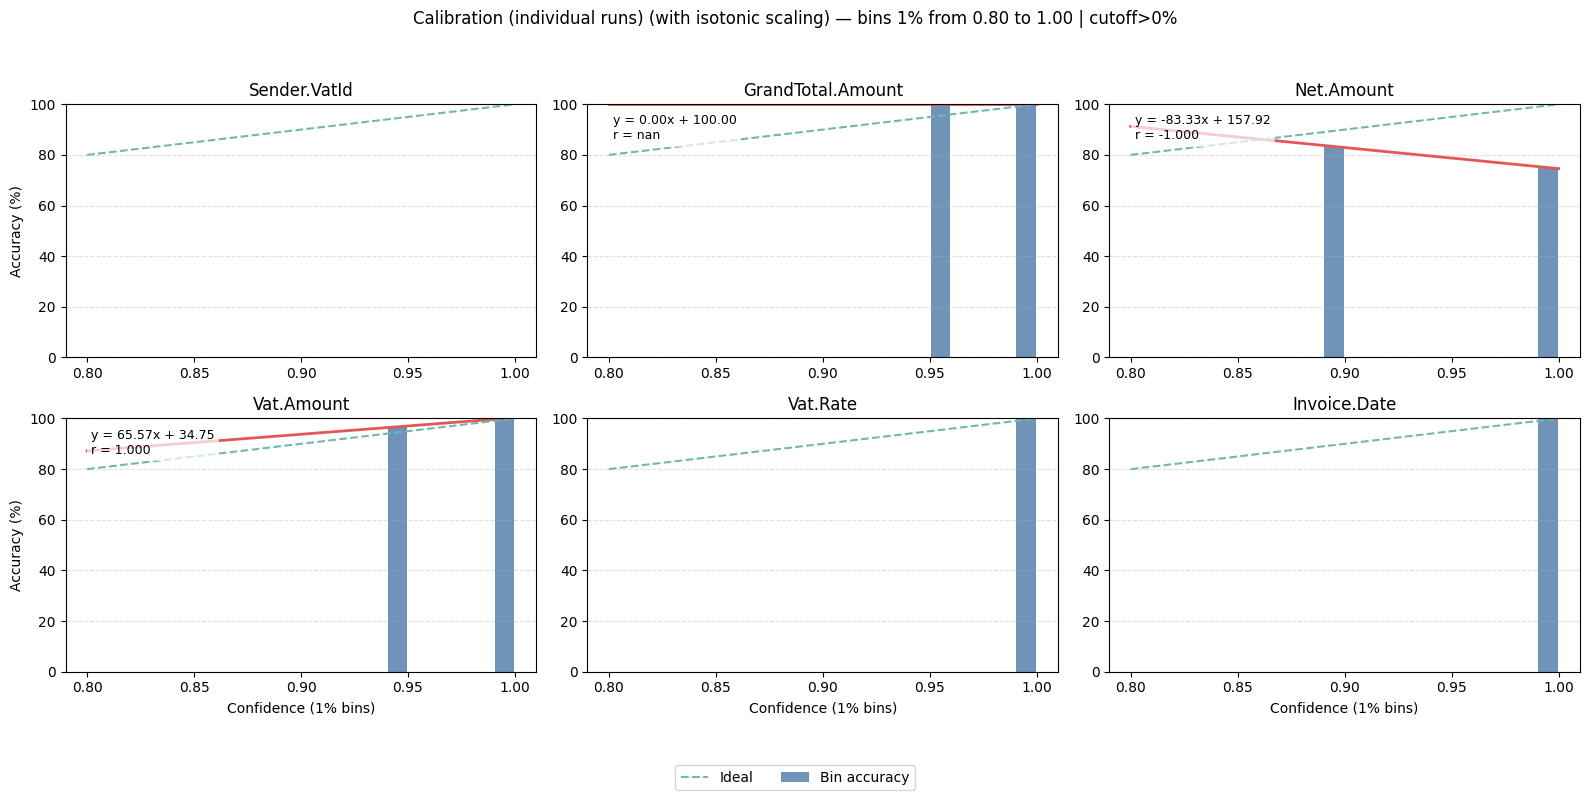

Saved: ..\Output\Prod-3-trace\calibration_runs_isotonic_grid_80_100_1pct_cut0.png


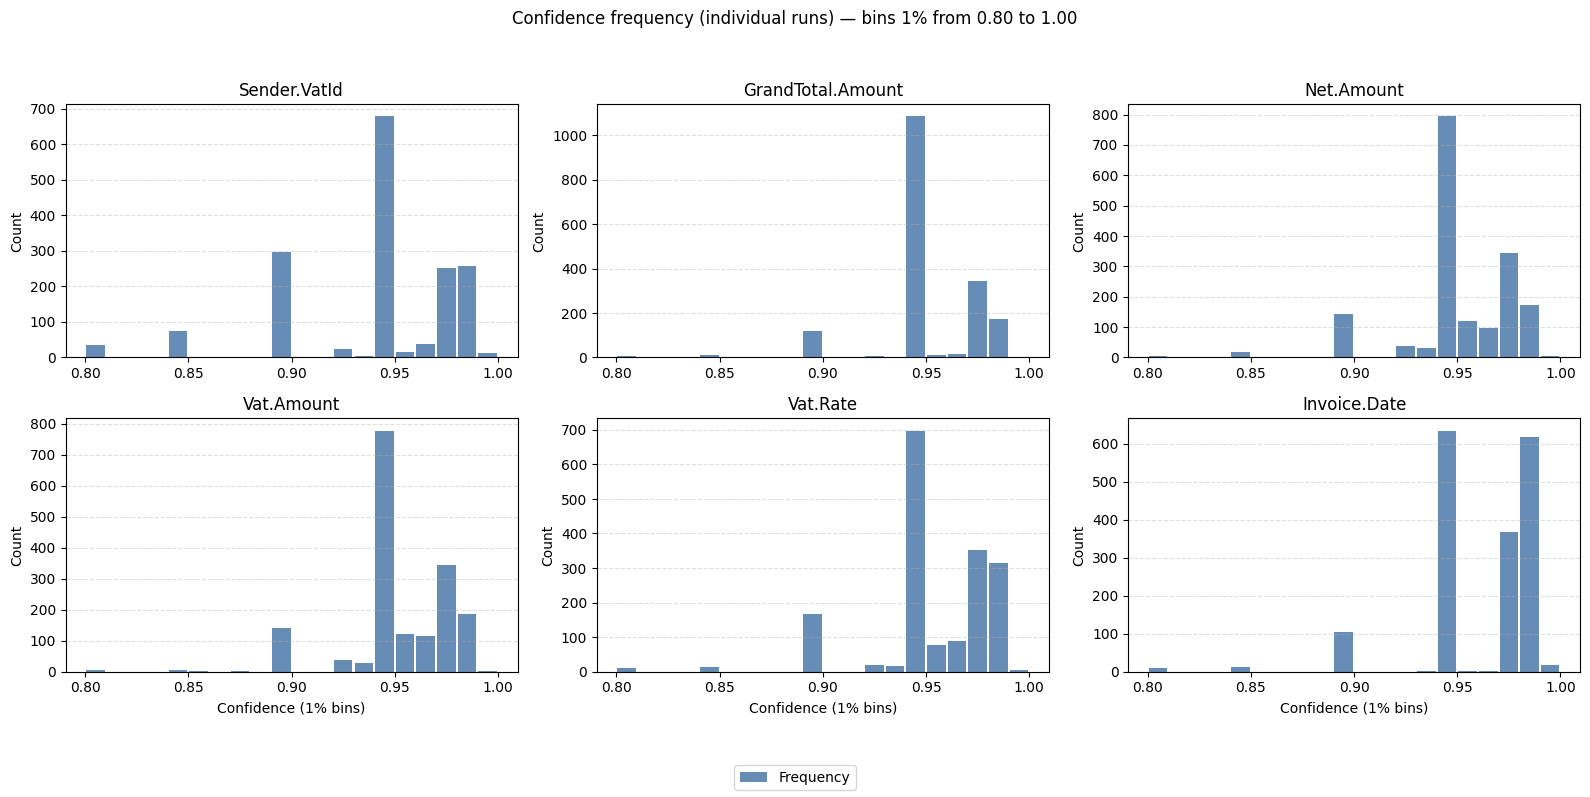

Saved: ..\Output\Prod-3-trace\frequency_runs_grid_80_100_1pct.png


In [ ]:
plot_calibration(
    f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs",
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    min_bin_pct=MIN_BIN_PCT,
    use_isotonic=True,
    train_by_field=train_by_field,
    test_by_field=test_by_field,
)

plot_confidence_frequency(
    f"../Output/{FOLDER_TO_VISUALIZE}",
    mode="runs",
    min_conf=MIN_CONF,
    max_conf=MAX_CONF,
    bin_width=BIN_WIDTH,
    train_by_field=train_by_field,
    test_by_field=test_by_field,
)
